In [1]:

# ── CELDA 1: IMPORTS Y CONEXIÓN 
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import gspread
from google.oauth2.service_account import Credentials

# Estilo global
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORES_METODO = {
    "LinearRegression":        "#2E86AB",
    "Ridge":                   "#A23B72",
    "RandomForestRegressor":   "#F18F01",
    "GradientBoostingRegressor": "#4CAF50",
}

COLORES_ARCHIVO = {
    "df_semanal.csv":  "#264653",
    "df_semanal_1.csv":"#2A9D8F",
    "df_semanal_2.csv":"#E9C46A",
    "df_semanal_3.csv":"#F4A261",
    "df_semanal_4.csv":"#E76F51",
}

LAGS_LABEL = {
    "df_semanal.csv":  "0 lags",
    "df_semanal_1.csv":"1 lag",
    "df_semanal_2.csv":"2 lags",
    "df_semanal_3.csv":"3 lags",
    "df_semanal_4.csv":"4 lags",
}


In [2]:

# LEER GOOGLE SHEETS 
SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]
SERVICE_ACCOUNT_FILE = "credenciales_google.json"
SHEET_URL = "https://docs.google.com/spreadsheets/d/17T0L6gza7vzD1vFh6OG2j3qOmlKCDRtFFu5HNma1Agk/edit?gid=836870544#gid=836870544"

def conectar_y_leer():
    creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
    client = gspread.authorize(creds)
    ws = client.open_by_url(SHEET_URL).get_worksheet(0)

    values = ws.get_all_values()   
    header = values[0]
    rows = values[1:]

    df = pd.DataFrame(rows, columns=header)
    return df

df_raw = conectar_y_leer()
print(f"Filas leídas: {len(df_raw)}")
print(df_raw.columns.tolist())



Filas leídas: 1160
['Archivo', 'Método', 'Target', 'FechaIni', 'FechaFin', 'RMSE', 'RMSE_baseline', 'RMSE_zeros', 'MAE', 'MAE_baseline', 'MAE_zeros', 'Estado', 'Alpha', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'learning_rate', 'subsample', 'FechaPredIni', 'FechaPredFin', 'FechaTrainIni', 'FechaTrainFin', 'ValorReal']


In [3]:
def parse_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s == "":
        return np.nan

    s = s.replace("\xa0", "").replace(" ", "").replace("%", "")

    # Caso tipo 1.234,56
    if "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            # Caso tipo 1,234.56
            s = s.replace(",", "")
    elif "," in s:
        # Caso tipo 0,00301
        s = s.replace(",", ".")

    return pd.to_numeric(s, errors="coerce")

In [4]:
def limpiar(df):
    df = df.copy()

    df = df[df["Estado"].astype(str).str.upper() == "DONE"].copy()

    num_cols = ["RMSE", "RMSE_baseline", "RMSE_zeros",
                "MAE", "MAE_baseline", "MAE_zeros"]

    for c in num_cols:
        df[c] = df[c].apply(parse_num)

    df["ETF"] = df["Target"].astype(str).str.replace("target_", "", regex=False)
    df["Lags"] = df["Archivo"].map(LAGS_LABEL).fillna("?")

    df["Mejora_vs_baseline"] = (
        (df["RMSE_baseline"] - df["RMSE"]) / df["RMSE_baseline"] * 100
    ).round(2)

    df["Mejora_vs_zeros"] = (
        (df["RMSE_zeros"] - df["RMSE"]) / df["RMSE_zeros"] * 100
    ).round(2)

    df["Bate_baseline"] = df["RMSE"] < df["RMSE_baseline"]
    df["Bate_zeros"] = df["RMSE"] < df["RMSE_zeros"]

    return df

In [5]:
df = limpiar(df_raw)


## RMSE medio por modelo y número de lags

In [6]:

# TABLAS RESUMEN
# TABLA RESUMEN GENERAL por Método y Archivo
print("\n" + "="*70)
print("TABLA 1 — RMSE medio por Método y Archivo (número de lags)")
print("="*70)

tabla1 = df.groupby(["Archivo","Método"])[["RMSE","RMSE_baseline","RMSE_zeros"]].mean().round(5)
tabla1["Mejora_vs_baseline(%)"] = (
    (tabla1["RMSE_baseline"] - tabla1["RMSE"]) / tabla1["RMSE_baseline"] * 100
).round(2)
tabla1["Mejora_vs_zeros(%)"] = (
    (tabla1["RMSE_zeros"] - tabla1["RMSE"]) / tabla1["RMSE_zeros"] * 100
).round(2)
print(tabla1.to_string())



TABLA 1 — RMSE medio por Método y Archivo (número de lags)
                                               RMSE  RMSE_baseline  RMSE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo          Método                                                                                                  
df_semanal.csv   GradientBoostingRegressor  0.00494        0.00717     0.00494                  31.10                0.00
                 LinearRegression           0.00784        0.00717     0.00494                  -9.34              -58.70
                 RandomForestRegressor      0.00491        0.00717     0.00494                  31.52                0.61
                 Ridge                      0.00490        0.00717     0.00494                  31.66                0.81
df_semanal_1.csv GradientBoostingRegressor  0.00491        0.00717     0.00494                  31.52                0.61
                 LinearRegression           0.01437        0.00717     0.00494        

Los tres modelos que funcionan bien, Ridge, Random Forest y Gradient Boosting, obtienen resultados muy parecidos en todas las configuraciones de lags. La diferencia entre ellos es muy pequeña, y en términos globales el mejor resultado lo consigue Ridge con 0 lags, con un RMSE medio de 0.00490. Frente al baseline ingenuo, la mejora es clara y estable, de alrededor del 31.7 %.

La Regresión Lineal queda claramente descartada. Su error aumenta mucho al añadir lags, hasta situarse muy por encima del baseline y del benchmark de ceros. Esto indica que, sin regularización, el modelo no es capaz de manejar bien la ampliación de variables explicativas.

El efecto de añadir lags es muy limitado. En los modelos buenos, el RMSE cambia muy poco entre 0 y 4 lags, y de hecho la mejor combinación global aparece con 0 lags. Esto sugiere que la información de retornos semanales pasados aporta muy poco valor adicional para este problema.

El benchmark de predicción cero resulta especialmente exigente: su RMSE medio es 0.00494, prácticamente igual al de los mejores modelos. Por eso, aunque Ridge mejora claramente al baseline ingenuo, la mejora frente a zeros es muy pequeña (0.66 %). Esto encaja con la naturaleza casi impredecible de los retornos semanales.

## MAE medio por modelo y número de lags

In [7]:
# TABLA 2 — MAE medio por Método y Archivo
print("\n" + "="*70)
print("TABLA 2 — MAE medio por Método y Archivo — Modelos semanales")
print("="*70)
tabla2 = df.groupby(["Archivo","Método"])[["MAE","MAE_baseline","MAE_zeros"]].mean().round(5)
tabla2["Mejora_vs_baseline(%)"] = ((tabla2["MAE_baseline"]-tabla2["MAE"])/tabla2["MAE_baseline"]*100).round(2)
tabla2["Mejora_vs_zeros(%)"]    = ((tabla2["MAE_zeros"]   -tabla2["MAE"])/tabla2["MAE_zeros"]   *100).round(2)
print(tabla2.to_string())


TABLA 2 — MAE medio por Método y Archivo — Modelos semanales
                                                MAE  MAE_baseline  MAE_zeros  Mejora_vs_baseline(%)  Mejora_vs_zeros(%)
Archivo          Método                                                                                                
df_semanal.csv   GradientBoostingRegressor  0.00372       0.00539    0.00369                  30.98               -0.81
                 LinearRegression           0.00605       0.00539    0.00369                 -12.24              -63.96
                 RandomForestRegressor      0.00367       0.00539    0.00369                  31.91                0.54
                 Ridge                      0.00365       0.00539    0.00369                  32.28                1.08
df_semanal_1.csv GradientBoostingRegressor  0.00367       0.00539    0.00369                  31.91                0.54
                 LinearRegression           0.01064       0.00539    0.00369                 -97.4

El MAE confirma la misma idea que el RMSE. El mejor resultado global vuelve a aparecer en Ridge con 0 lags, con un MAE medio de 0.00365, y una mejora de alrededor del 32.3 % frente al baseline. Random Forest y Gradient Boosting quedan muy cerca, por lo que los tres pueden considerarse modelos competitivos.

La Regresión Lineal vuelve a mostrar un comportamiento claramente peor, lo que refuerza que no es una opción adecuada para este problema.

Que RMSE y MAE cuenten una historia tan parecida es una buena señal, porque indica que el comportamiento del modelo es estable y no depende solo de unos pocos errores extremos. El error absoluto medio de los mejores modelos ronda el 0.36 %–0.38 % de retorno semanal, una magnitud razonable para este tipo de activos.

## RMSE por modelo y configuración de lags — gráfico de barras

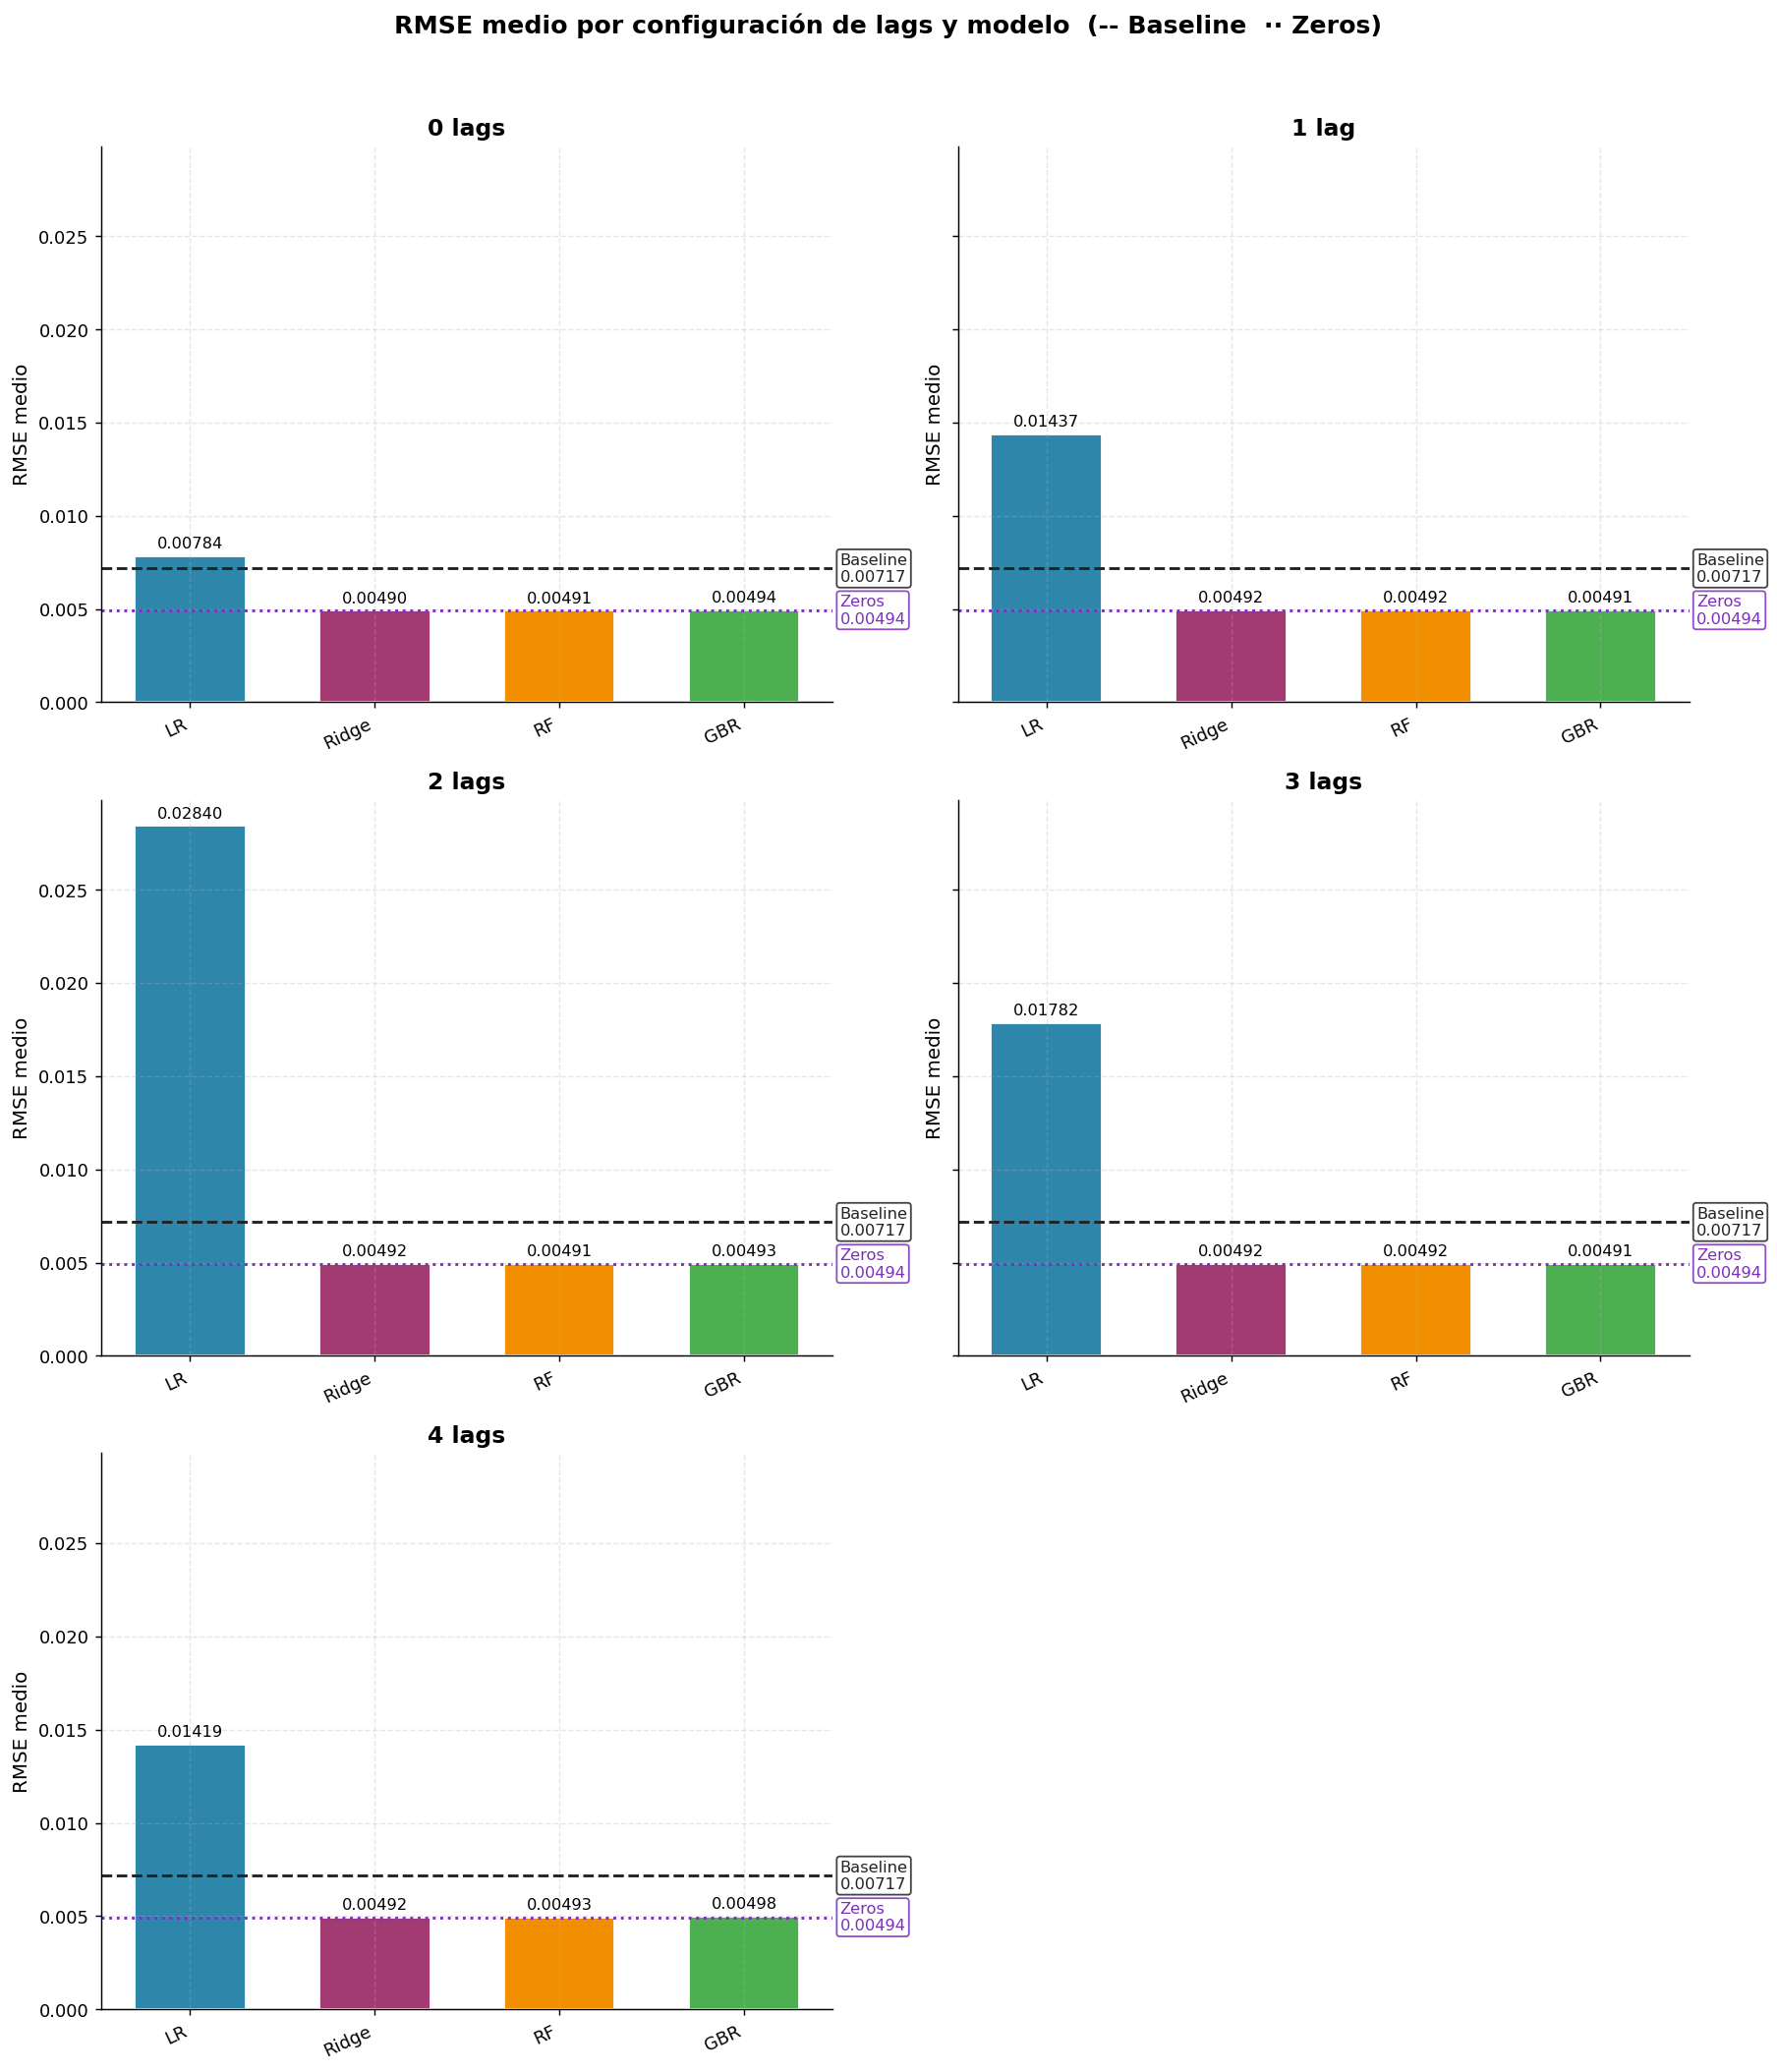

In [8]:
import math
import matplotlib.pyplot as plt

# GRAFICO TABLA 1 — RMSE por Archivo y Método (más grande y en varios subplots)
archivos_orden = [
    "df_semanal.csv", "df_semanal_1.csv", "df_semanal_2.csv",
    "df_semanal_3.csv", "df_semanal_4.csv"
]

archivos_pres = [a for a in archivos_orden if a in df["Archivo"].unique()]
metodos_ord   = list(COLORES_METODO.keys())
n             = len(archivos_pres)

# ---- CAMBIO IMPORTANTE: varios subplots en rejilla ----
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.5 * nrows), sharey=True)
axes = axes.flatten()  # para recorrerlos fácil aunque haya varias filas

for ax, archivo in zip(axes, archivos_pres):
    sub      = df[df["Archivo"] == archivo]
    por_met  = sub.groupby("Método")["RMSE"].mean().reindex(metodos_ord).dropna()
    baseline = sub["RMSE_baseline"].mean()
    zeros    = sub["RMSE_zeros"].mean()

    x       = range(len(por_met))
    colores = [COLORES_METODO.get(m, "#888") for m in por_met.index]

    bars = ax.bar(x, por_met.values, color=colores, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.5f", fontsize=9, padding=3)

    ax.axhline(baseline, color="#222", linestyle="--", linewidth=1.6)
    ax.axhline(zeros,    color="#7B2FBE", linestyle=":", linewidth=1.6)

    ax.annotate(
        f"Baseline\n{baseline:.5f}",
        xy=(1.01, baseline), xycoords=("axes fraction", "data"),
        fontsize=9, color="#222", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#222", alpha=0.85)
    )

    ax.annotate(
        f"Zeros\n{zeros:.5f}",
        xy=(1.01, zeros), xycoords=("axes fraction", "data"),
        fontsize=9, color="#7B2FBE", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#7B2FBE", alpha=0.85)
    )

    etiq = [
        m.replace("GradientBoostingRegressor", "GBR")
         .replace("RandomForestRegressor", "RF")
         .replace("LinearRegression", "LR")
        for m in por_met.index
    ]

    ax.set_xticks(list(x))
    ax.set_xticklabels(etiq, rotation=25, ha="right", fontsize=10)
    ax.set_title(LAGS_LABEL.get(archivo, archivo), fontsize=13, fontweight="bold")
    ax.set_ylabel("RMSE medio", fontsize=11)

# ocultar ejes vacíos si sobran
for j in range(len(archivos_pres), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "RMSE medio por configuración de lags y modelo  (-- Baseline  ·· Zeros)",
    fontsize=14, fontweight="bold", y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("G02_rmse_por_archivo_metodo.png", dpi=150, bbox_inches="tight")
plt.show()

La imagen muestra con claridad la diferencia entre modelos: las barras de Ridge, RF y GBR quedan todas cerca de la línea de ceros, mientras que las de Regresión Lineal sobresalen mucho hacia arriba en cuanto se añaden lags.

Que los tres mejores modelos estén tan cerca del benchmark de ceros no es un problema; es lo esperado cuando trabajamos con retornos semanals de mercado. Lo importante es que todos ellos están por debajo de la línea del baseline, es decir, cometen menos error que simplemente repetir el último retorno observado.

La altura de las barras prácticamente no cambia de un subplot a otro (de 0 a 4 lags), lo que confirma que el número de lags no afecta al rendimiento de los modelos buenos.

## MAE por modelo y configuración de lags — gráfico de barras

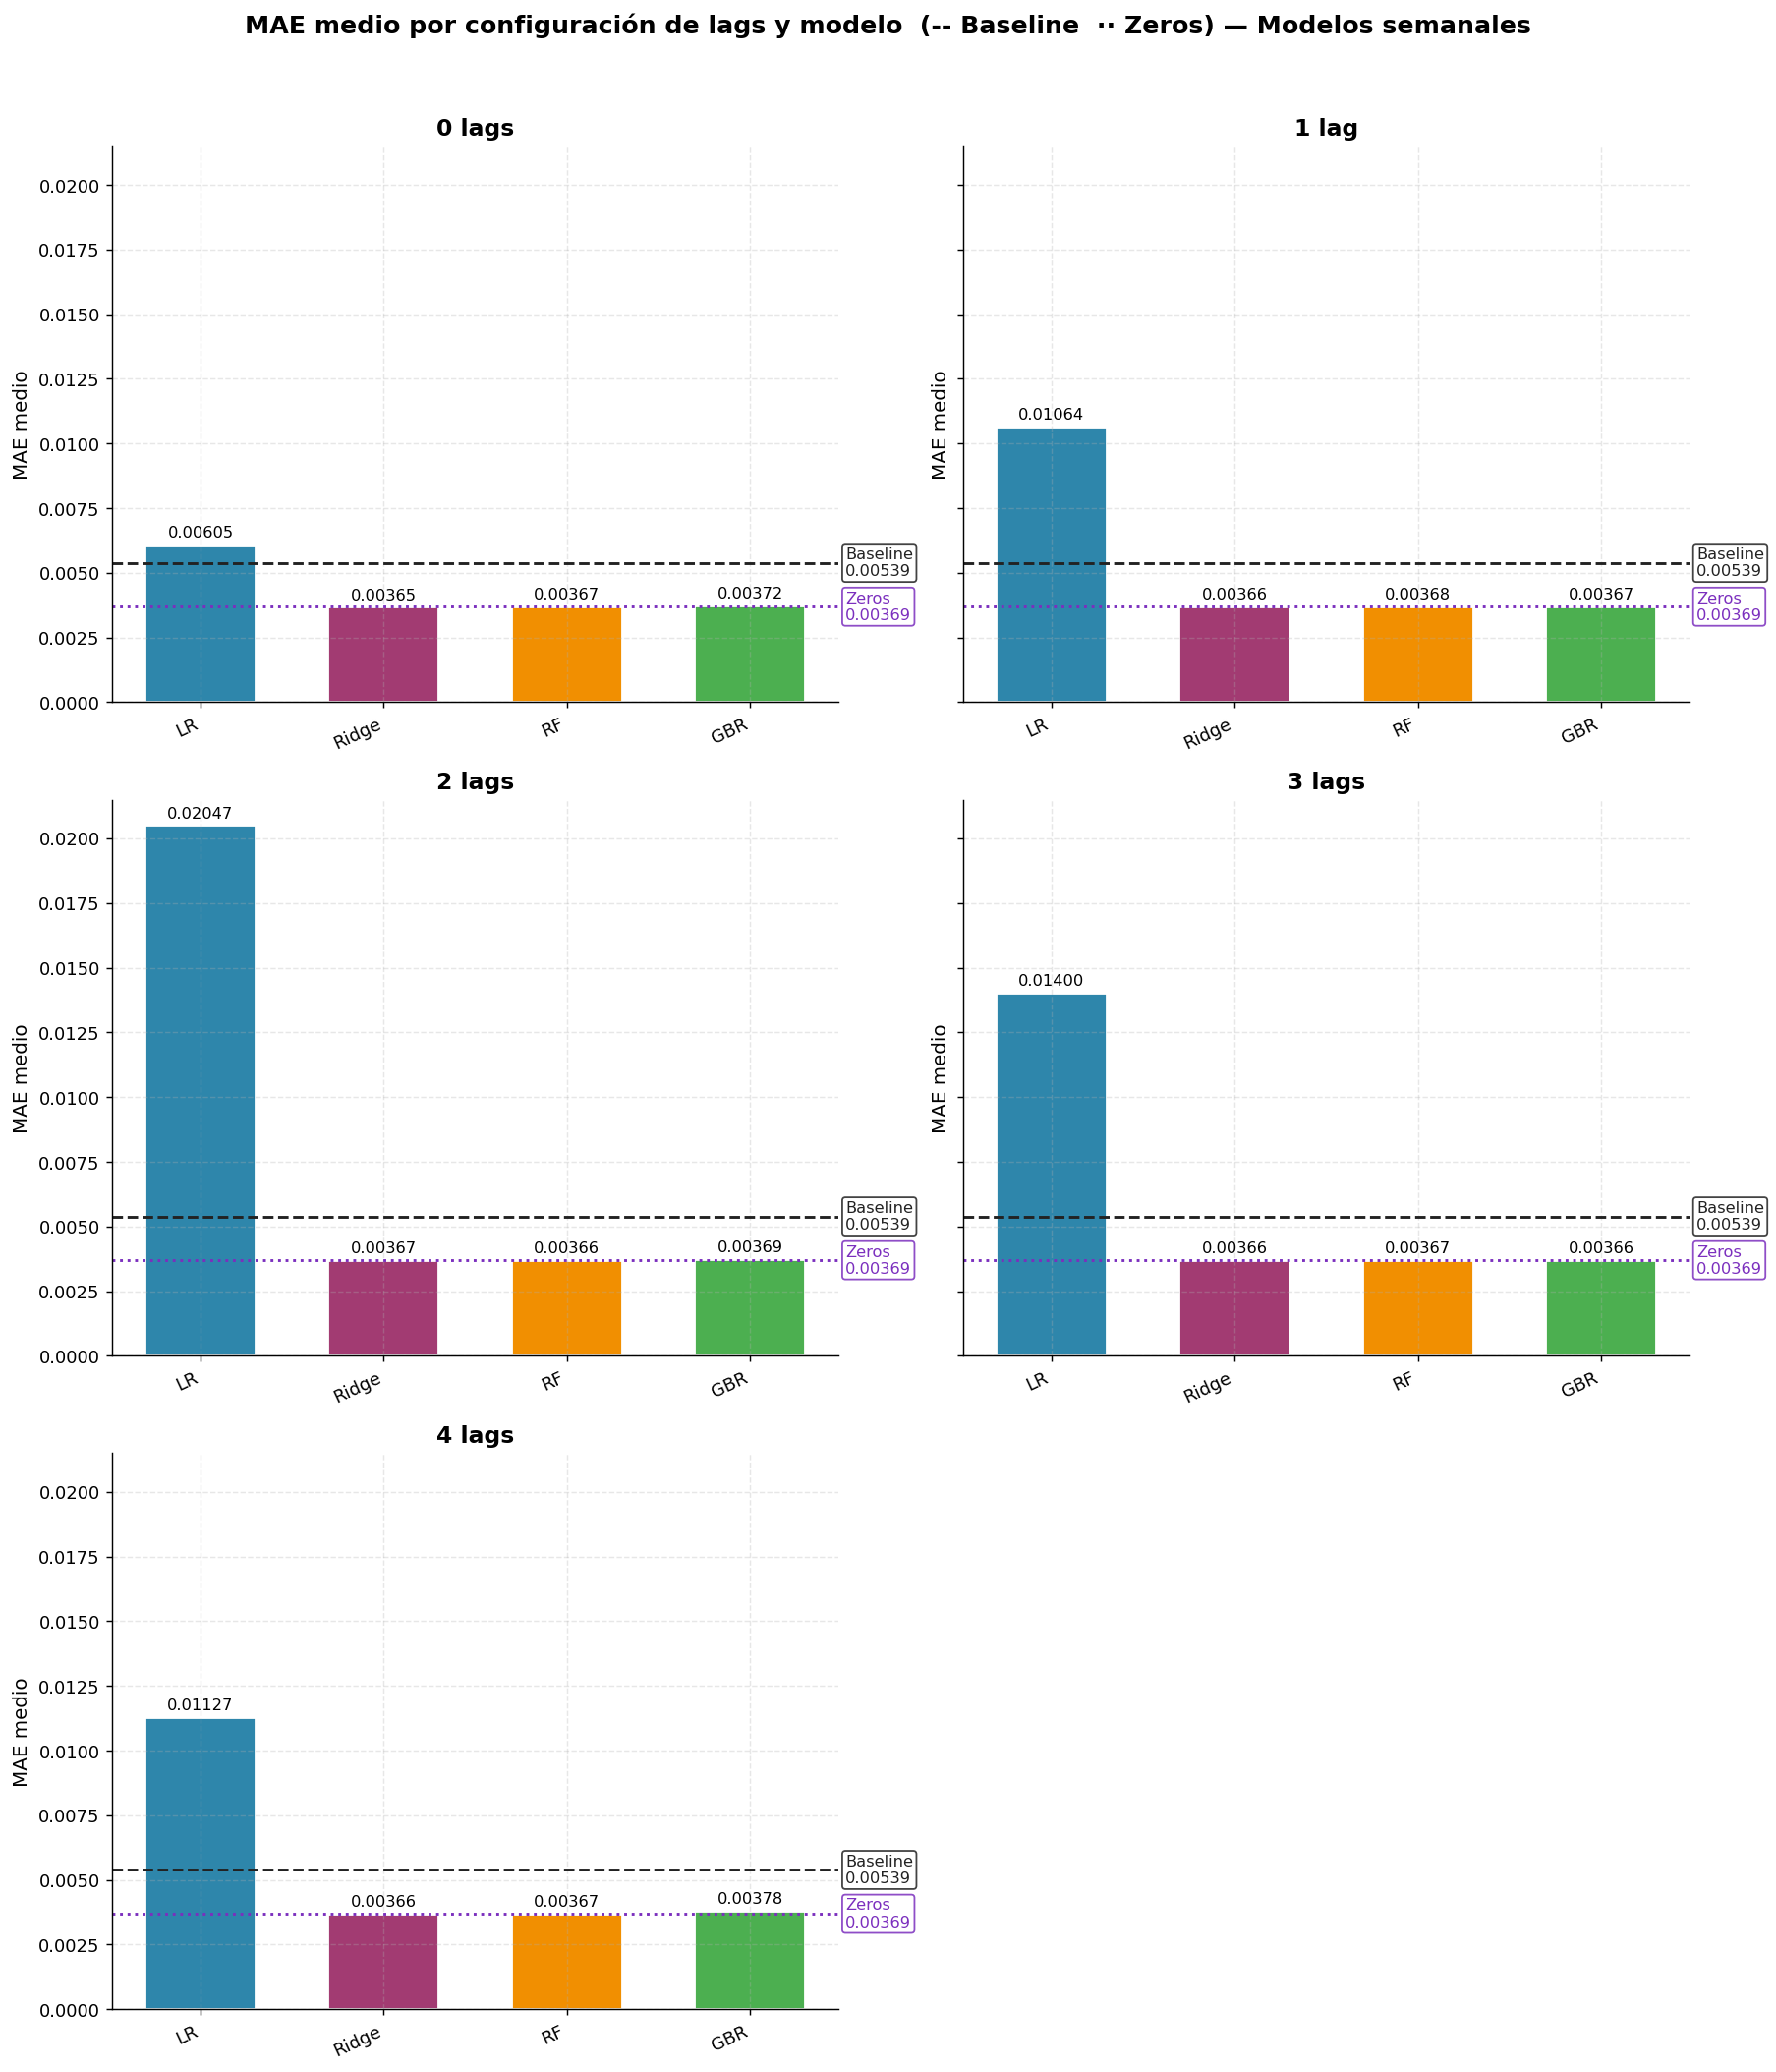

In [9]:
import math
archivos_orden_mae = ["df_semanal.csv","df_semanal_1.csv","df_semanal_2.csv","df_semanal_3.csv","df_semanal_4.csv"]
archivos_pres_mae  = [a for a in archivos_orden_mae if a in df["Archivo"].unique()]
ncols_mae = 2
nrows_mae = math.ceil(len(archivos_pres_mae) / ncols_mae)
fig, axes = plt.subplots(nrows_mae, ncols_mae, figsize=(14, 5.5*nrows_mae), sharey=True)
axes = axes.flatten()
for ax, archivo in zip(axes, archivos_pres_mae):
    sub      = df[df["Archivo"] == archivo]
    por_met  = sub.groupby("Método")["MAE"].mean().reindex(list(COLORES_METODO.keys())).dropna()
    baseline = sub["MAE_baseline"].mean()
    zeros    = sub["MAE_zeros"].mean()
    x        = range(len(por_met))
    colores  = [COLORES_METODO.get(m, "#888") for m in por_met.index]
    bars = ax.bar(x, por_met.values, color=colores, edgecolor="white", width=0.6)
    ax.bar_label(bars, fmt="%.5f", fontsize=9, padding=3)
    ax.axhline(baseline, color="#222",    linestyle="--", linewidth=1.6)
    ax.axhline(zeros,    color="#7B2FBE", linestyle=":",  linewidth=1.6)
    ax.annotate(f"Baseline\n{baseline:.5f}", xy=(1.01,baseline), xycoords=("axes fraction","data"),
        fontsize=9, color="#222", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#222", alpha=0.85))
    ax.annotate(f"Zeros\n{zeros:.5f}", xy=(1.01,zeros), xycoords=("axes fraction","data"),
        fontsize=9, color="#7B2FBE", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#7B2FBE", alpha=0.85))
    etiq = [m.replace("GradientBoostingRegressor","GBR").replace("RandomForestRegressor","RF").replace("LinearRegression","LR")
            for m in por_met.index]
    ax.set_xticks(list(x)); ax.set_xticklabels(etiq, rotation=25, ha="right", fontsize=10)
    ax.set_title(LAGS_LABEL.get(archivo, archivo), fontsize=13, fontweight="bold")
    ax.set_ylabel("MAE medio", fontsize=11)
for j in range(len(archivos_pres_mae), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("MAE medio por configuración de lags y modelo  (-- Baseline  ·· Zeros) — Modelos semanales",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

El gráfico de MAE cuenta exactamente la misma historia que el de RMSE. Las barras de los tres modelos buenos son muy similares en altura entre sí y entre configuraciones de lags.

La Regresión Lineal vuelve a dispararse, aunque algo menos que en RMSE porque el MAE penaliza menos los errores muy grandes. Esto confirma que la LR no solo comete errores grandes, sino que los comete con frecuencia.

Para los modelos buenos, las barras de MAE son más cortas que las de RMSE, como es normal. La diferencia entre ambas métricas es moderada, lo que indica que no hay semanas concretas donde el modelo falle de forma catastrófica.

In [10]:

# CONFIGURACIÓN ÚNICA

ETF_ELIMINADOS = {"BIL", "EWY", "GLD", "IAU", "SHY"}

GRUPOS_ETF = {
    "Mercado estadounidense (Core US)": [
        "SPY","IVV","VOO","QQQ","VTI","ITOT","DIA","IWM","IJR","MDY",
    ],
    "Factores y estilos": [
        "VUG","IWF","VTV","IWD","SCHD","VIG","DVY","MTUM","QUAL","USMV","VLUE",
    ],
    "Sectores económicos": [
        "XLK","XLF","XLV","XLY","XLP","XLE","XLI","XLU","XLB","XLRE",
    ],
    "Mercados internacionales": [
        "VEA","IEFA","VWO","IEMG","EEM","EFA",
        "EWJ","EWG","EWU","EWQ","INDA","EWZ","FXI","MCHI","EWT",
    ],
    "Renta fija": [
        "BND","AGG","IEF","TLT","LQD","HYG","JNK","TIP",
    ],
    "Materias primas y activos reales": [
        "SLV","USO","DBC","VNQ",
    ],
}

ORDEN_GRUPOS = list(GRUPOS_ETF.keys())
etf_to_grupo = {etf: g for g, etfs in GRUPOS_ETF.items() for etf in etfs}



# FUNCIONES AUXILIARES
#

def pct_mejora(base, modelo):
    if pd.isna(base) or pd.isna(modelo) or base == 0:
        return np.nan
    return (base - modelo) / base * 100


def preparar_base(df):
    out = df[~df["ETF"].isin(ETF_ELIMINADOS)].copy()

    for c in ["RMSE","RMSE_baseline","RMSE_zeros","MAE","MAE_baseline","MAE_zeros"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna(subset=["ETF","Archivo","Método","RMSE","MAE"]).copy()
    return out


def enriquecer_df(out):
    out = out.copy()

    out["Grupo"] = out["ETF"].map(etf_to_grupo).fillna("Sin grupo")
    out["Lags"] = out["Archivo"].map(LAGS_LABEL).fillna(out["Archivo"])
    out["Método_c"] = out["Método"].replace({
        "GradientBoostingRegressor": "GBR",
        "RandomForestRegressor": "RF",
        "LinearRegression": "LR",
    })

    out["Mej_RMSE_baseline(%)"] = out.apply(lambda r: pct_mejora(r["RMSE_baseline"], r["RMSE"]), axis=1)
    out["Mej_RMSE_zeros(%)"]    = out.apply(lambda r: pct_mejora(r["RMSE_zeros"], r["RMSE"]), axis=1)
    out["Mej_MAE_baseline(%)"]  = out.apply(lambda r: pct_mejora(r["MAE_baseline"], r["MAE"]), axis=1)
    out["Mej_MAE_zeros(%)"]     = out.apply(lambda r: pct_mejora(r["MAE_zeros"], r["MAE"]), axis=1)

    out["Bate_zeros"] = out["RMSE"] < out["RMSE_zeros"]

    out["_ord"] = out["Grupo"].map({g: i for i, g in enumerate(ORDEN_GRUPOS)}).fillna(999)
    out = out.sort_values(["_ord", "RMSE", "MAE", "ETF"]).drop(columns="_ord")

    return out


def resumen_consistente(sub):
    rmse_m   = sub["RMSE"].mean()
    mae_m    = sub["MAE"].mean()
    rmse_b_m = sub["RMSE_baseline"].mean()
    rmse_z_m = sub["RMSE_zeros"].mean()
    mae_b_m  = sub["MAE_baseline"].mean()
    mae_z_m  = sub["MAE_zeros"].mean()

    return {
        "RMSE medio": rmse_m,
        "MAE medio": mae_m,
        "Mejora RMSE baseline": pct_mejora(rmse_b_m, rmse_m),
        "Mejora RMSE zeros": pct_mejora(rmse_z_m, rmse_m),
        "Mejora MAE baseline": pct_mejora(mae_b_m, mae_m),
        "Mejora MAE zeros": pct_mejora(mae_z_m, mae_m),
    }


def imprimir_tabla_por_grupos(df_in, titulo):
    dfx = enriquecer_df(df_in)
    print("\n")
    print(titulo)
    print("="*120)

    cols = [
        "Lags", "Método_c", "RMSE", "MAE",
        "Mej_RMSE_baseline(%)", "Mej_RMSE_zeros(%)",
        "Mej_MAE_baseline(%)", "Mej_MAE_zeros(%)"
    ]

    ren = {
        "Método_c": "Método",
        "Mej_RMSE_baseline(%)": "Mej.RMSE_base(%)",
        "Mej_RMSE_zeros(%)":    "Mej.RMSE_zeros(%)",
        "Mej_MAE_baseline(%)":  "Mej.MAE_base(%)",
        "Mej_MAE_zeros(%)":     "Mej.MAE_zeros(%)",
    }

    for grupo in ORDEN_GRUPOS + ["Sin grupo"]:
        sub = dfx[dfx["Grupo"] == grupo].copy()
        if sub.empty:
            continue

        print(f"\n{grupo.upper()} ({len(sub)} ETFs)")

        tabla = sub.set_index("ETF")[cols].rename(columns=ren)

        for c in ["RMSE", "MAE"]:
            tabla[c] = tabla[c].map(lambda x: f"{x:.5f}" if pd.notnull(x) else "")

        for c in ["Mej.RMSE_base(%)", "Mej.RMSE_zeros(%)", "Mej.MAE_base(%)", "Mej.MAE_zeros(%)"]:
            tabla[c] = tabla[c].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "")

        print(tabla.to_string())

        res = resumen_consistente(sub)
        metodo_dom = sub["Método_c"].value_counts()
        lags_dom = sub["Lags"].value_counts()

        print("\n  Resumen del grupo:")
        print(f"  → RMSE medio          : {res['RMSE medio']:.5f}")
        print(f"  → MAE medio           : {res['MAE medio']:.5f}")
        print(f"  → Mejora RMSE baseline: {res['Mejora RMSE baseline']:.2f}%")
        print(f"  → Mejora RMSE zeros   : {res['Mejora RMSE zeros']:.2f}%")
        print(f"  → Mejora MAE baseline : {res['Mejora MAE baseline']:.2f}%")
        print(f"  → Mejora MAE zeros    : {res['Mejora MAE zeros']:.2f}%")
        print(f"  → ETFs que baten zeros: {int(sub['Bate_zeros'].sum())}/{len(sub)}")
        print(f"  → Modelo dominante    : {metodo_dom.index[0]} ({metodo_dom.iloc[0]} ETFs)")
        print(f"  → Lags dominante      : {lags_dom.index[0]} ({lags_dom.iloc[0]} ETFs)")
        if len(lags_dom) > 1:
            print("  → Distribución lags   : " + ", ".join(f"{l}: {n}" for l, n in lags_dom.items()))

        print("\n" + "-"*100)
        print("\n")

    

def seleccionar_modelo_global(df_base):
    tabla1_sel = (
        df_base
        .groupby(["Archivo", "Método"], as_index=False)
        .agg(
            RMSE=("RMSE", "mean"),
            MAE=("MAE", "mean"),
            RMSE_baseline=("RMSE_baseline", "mean"),
            RMSE_zeros=("RMSE_zeros", "mean"),
            MAE_baseline=("MAE_baseline", "mean"),
            MAE_zeros=("MAE_zeros", "mean"),
        )
    )

    tabla1_sel["Mejora_vs_baseline(%)"] = tabla1_sel.apply(
        lambda r: pct_mejora(r["RMSE_baseline"], r["RMSE"]), axis=1
    ).round(2)

    tabla1_sel["Mejora_vs_zeros(%)"] = tabla1_sel.apply(
        lambda r: pct_mejora(r["RMSE_zeros"], r["RMSE"]), axis=1
    ).round(2)

    fila = tabla1_sel.sort_values(["RMSE", "MAE", "Archivo", "Método"]).iloc[0]
    return tabla1_sel, fila




df_base = preparar_base(df)

## Modelo global con MEJOR RMSE (RIDGE + DF_SEMANAL SIN LAGS)

In [11]:
tabla1_sel, fila_ganadora = seleccionar_modelo_global(df_base)

archivo_ganador = fila_ganadora["Archivo"]
metodo_ganador = fila_ganadora["Método"]

print("MENOR RMSE POR ARCHIVO Y MÉTODO")
print(f"Archivo ganador : {archivo_ganador} ({LAGS_LABEL.get(archivo_ganador, archivo_ganador)})")
print(f"Método ganador  : {metodo_ganador}")
print(f"RMSE medio      : {fila_ganadora['RMSE']:.5f}")
print(f"MAE medio       : {fila_ganadora['MAE']:.5f}")
print(f"Mejora baseline : {fila_ganadora['Mejora_vs_baseline(%)']:.2f}%")
print(f"Mejora zeros    : {fila_ganadora['Mejora_vs_zeros(%)']:.2f}%")

df_sel = df_base[
    (df_base["Archivo"] == archivo_ganador) &
    (df_base["Método"] == metodo_ganador)
].copy()

df_sel = (
    df_sel
    .sort_values(["ETF", "RMSE", "MAE"])
    .drop_duplicates(subset=["ETF"], keep="first")
)

imprimir_tabla_por_grupos(
    df_sel,
    "Resultados por ETF del modelo global ganador, agrupados por grupo"
)

MENOR RMSE POR ARCHIVO Y MÉTODO
Archivo ganador : df_semanal.csv (0 lags)
Método ganador  : Ridge
RMSE medio      : 0.00490
MAE medio       : 0.00365
Mejora baseline : 31.67%
Mejora zeros    : 0.66%


Resultados por ETF del modelo global ganador, agrupados por grupo

MERCADO ESTADOUNIDENSE (CORE US) (10 ETFs)
        Lags Método     RMSE      MAE Mej.RMSE_base(%) Mej.RMSE_zeros(%) Mej.MAE_base(%) Mej.MAE_zeros(%)
ETF                                                                                                      
DIA   0 lags  Ridge  0.00440  0.00342           35.58%             1.57%          34.61%            2.01%
VOO   0 lags  Ridge  0.00455  0.00338           36.89%             2.36%          35.74%            2.31%
SPY   0 lags  Ridge  0.00458  0.00338           37.09%             2.35%          35.86%            2.59%
IVV   0 lags  Ridge  0.00459  0.00339           37.30%             2.34%          35.92%            2.59%
VTI   0 lags  Ridge  0.00468  0.00347           36.15

El mejor modelo global por combinación de archivo y método es Ridge con df_semanal.csv (0 lags). Además, en la tabla por grupos se ve que la mejora frente al baseline se mantiene en prácticamente todos los grupos de ETFs. 

Eso sí, frente al benchmark de zeros la mejora es mucho menor y en algunos ETFs concretos puede llegar a ser casi nula o incluso ligeramente negativa. Por tanto, la conclusión correcta no es que el modelo gane ampliamente a zeros, sino que gana con claridad al baseline ingenuo y solo de forma ligera al benchmark de ceros.

### Visualmente, este sería el rnaking de etfs que baten al modelo zeros con este mejor rmse (Ridge + df_Semanal sin lags)

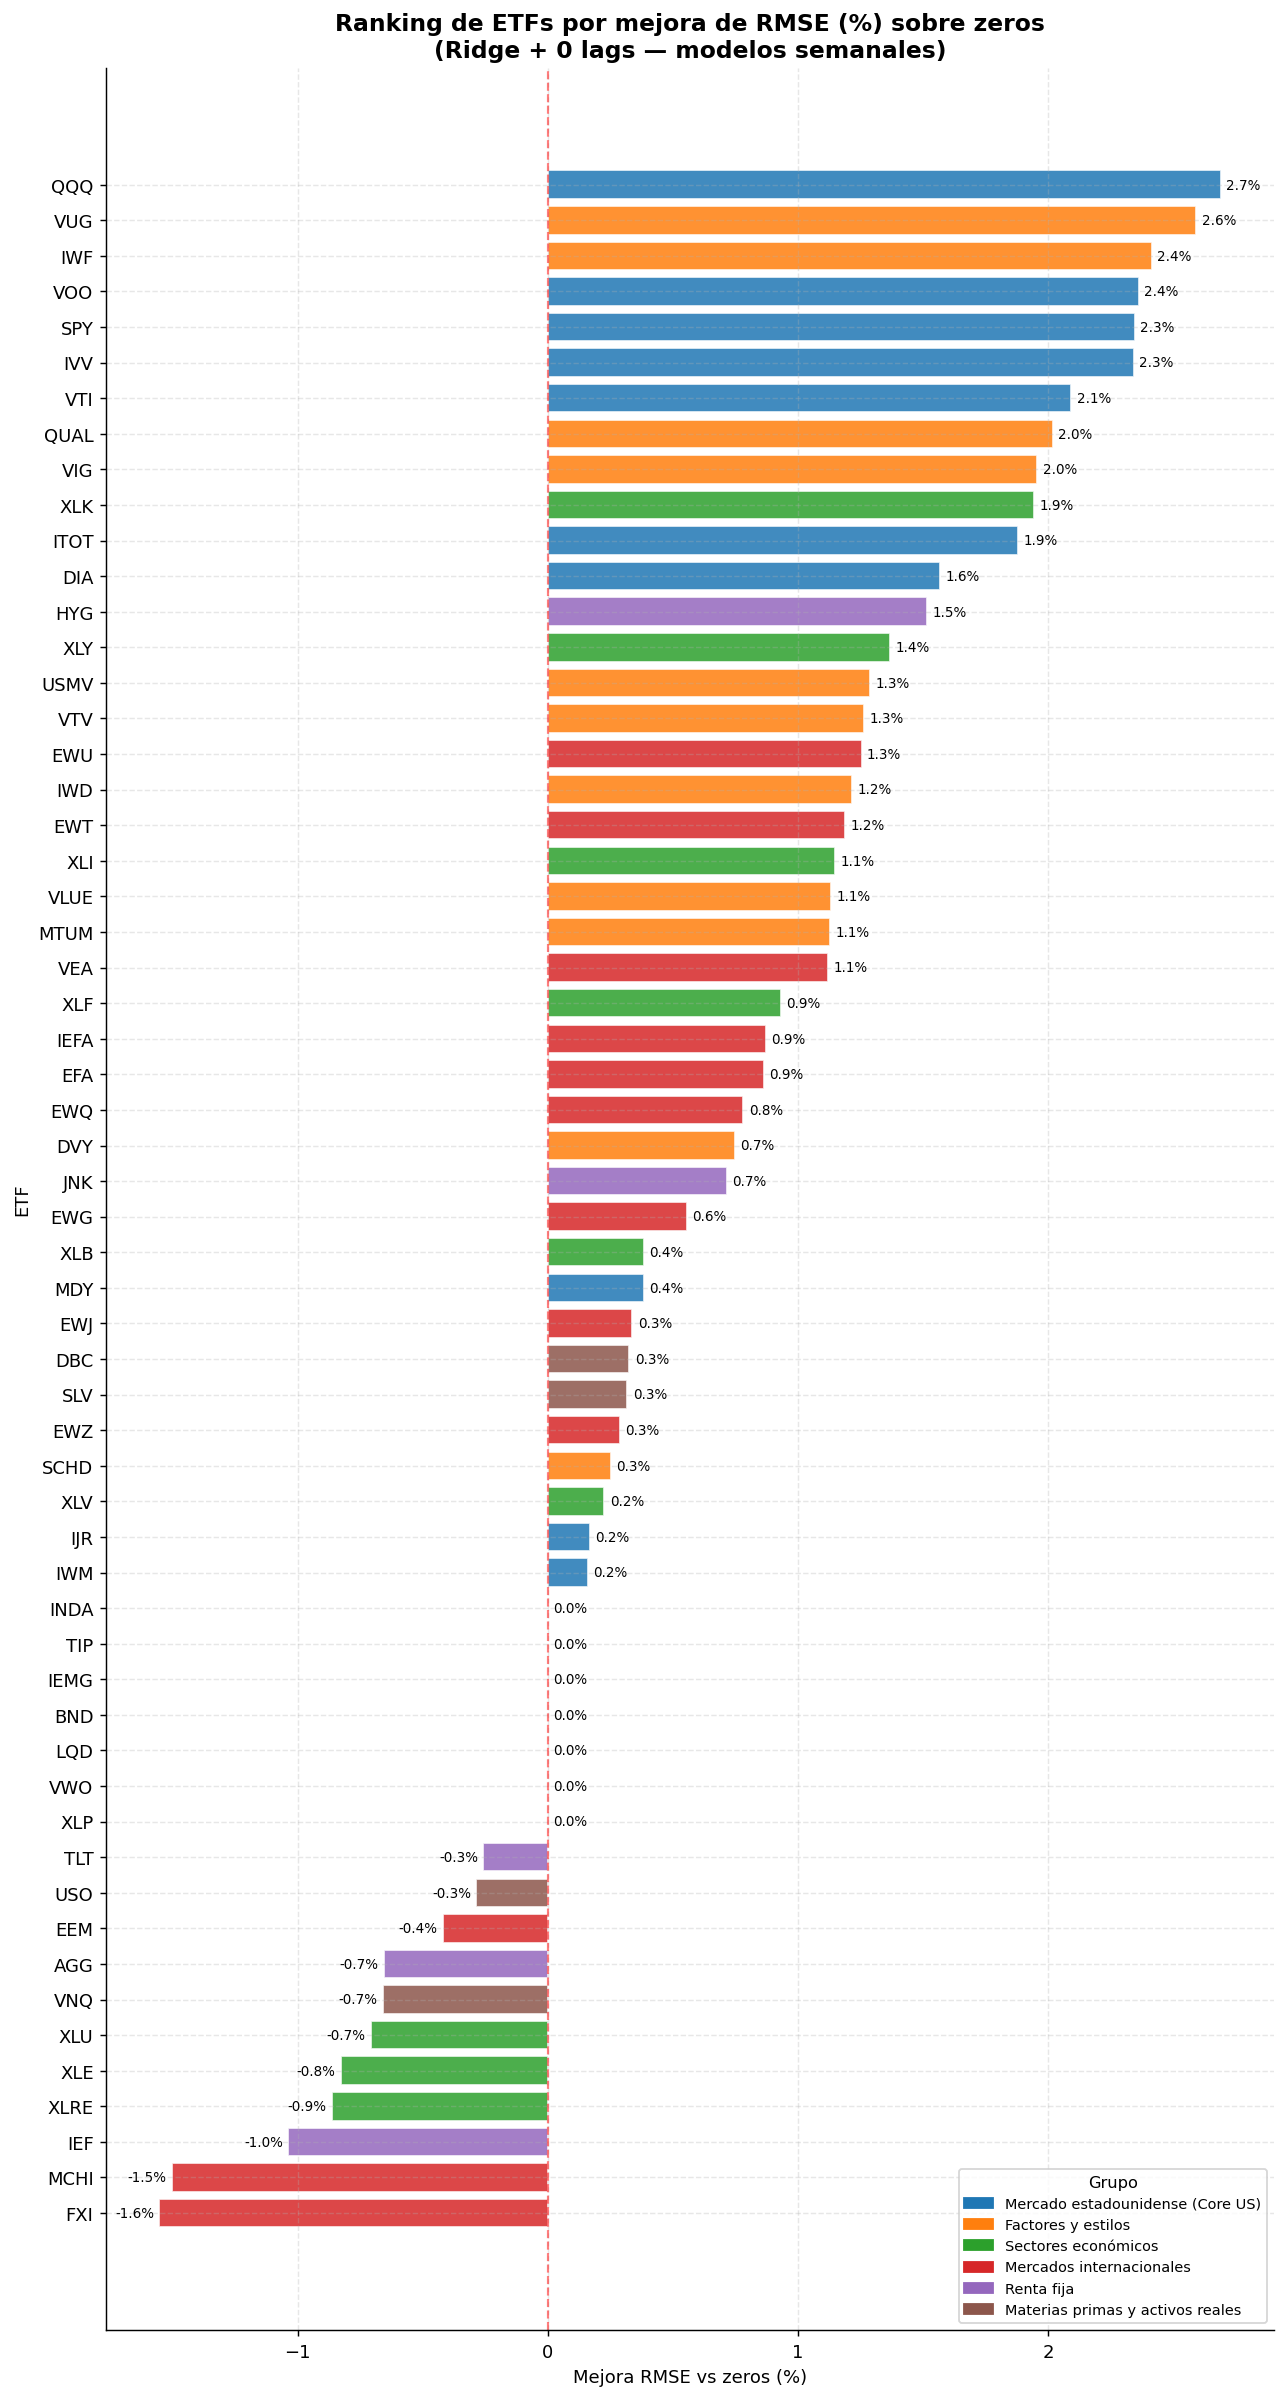

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# RANKING DE ETFs con un modelo fijo:
# Ridge + df_semanal.csv (0 lags)


df_rank = df_base[
    (df_base["Método"] == "Ridge") &
    (df_base["Archivo"] == "df_semanal.csv")
].copy()

# por si hubiera duplicados raros
df_rank = (
    df_rank
    .sort_values(["ETF", "RMSE", "MAE"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

# añadir columnas auxiliares y mejoras
df_rank = enriquecer_df(df_rank)

# ordenar por mejora frente a zeros
df_rank = df_rank.sort_values("Mej_RMSE_zeros(%)", ascending=True)

COLORES_GRUPO_R = {
    "Mercado estadounidense (Core US)": "#1f77b4",
    "Factores y estilos": "#ff7f0e",
    "Sectores económicos": "#2ca02c",
    "Mercados internacionales": "#d62728",
    "Renta fija": "#9467bd",
    "Materias primas y activos reales": "#8c564b",
    "Sin grupo": "#7f7f7f",
}

colores_r = [COLORES_GRUPO_R.get(g, "#888") for g in df_rank["Grupo"]]

fig, ax = plt.subplots(figsize=(10, max(8, len(df_rank) * 0.32)))

bars_r = ax.barh(
    df_rank["ETF"],
    df_rank["Mej_RMSE_zeros(%)"],
    color=colores_r,
    edgecolor="white",
    alpha=0.85
)

ax.bar_label(bars_r, fmt="%.1f%%", fontsize=7.5, padding=3)
ax.axvline(0, color="red", linestyle="--", alpha=0.5, linewidth=1.2)

patches_r = [
    mpatches.Patch(color=COLORES_GRUPO_R[g], label=g)
    for g in ORDEN_GRUPOS
    if g in df_rank["Grupo"].values
]

ax.legend(
    handles=patches_r,
    title="Grupo",
    fontsize=8,
    title_fontsize=9,
    loc="lower right"
)

ax.set_title(
    "Ranking de ETFs por mejora de RMSE (%) sobre zeros\n"
    "(Ridge + 0 lags — modelos semanales)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Mejora RMSE vs zeros (%)")
ax.set_ylabel("ETF")

plt.tight_layout()
plt.show()

La mayoría de ETFs tienen su barra a la derecha de la línea roja, es decir, el modelo mejora sobre el zeros para casi todos los activos.

Este ranking es práctico para decidir en qué ETFs merece más la pena confiar en el modelo a la hora de tomar decisiones de inversión. Vemos que mejora sobre todo en Factores y estilos y en ,ercados estadounidenses.

In [13]:
# PREPARAR DATOS PARA LAS GRÁFICAS FINALES

# Solo archivos semanales
archivos_semanales = list(LAGS_LABEL.keys())

# Base semanal limpia
df_sem = preparar_base(df)
df_sem = df_sem[df_sem["Archivo"].isin(archivos_semanales)].copy()

# Mejor modelo por ETF: menor RMSE y, si empata, menor MAE
df_mejor = (
    df_sem
    .sort_values(["ETF", "RMSE", "MAE", "Archivo", "Método"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

# Enriquecer una sola vez
df_mejor = enriquecer_df(df_mejor)

## Heatmap: mejora de RMSE por ETF y modelo

### ZEROS

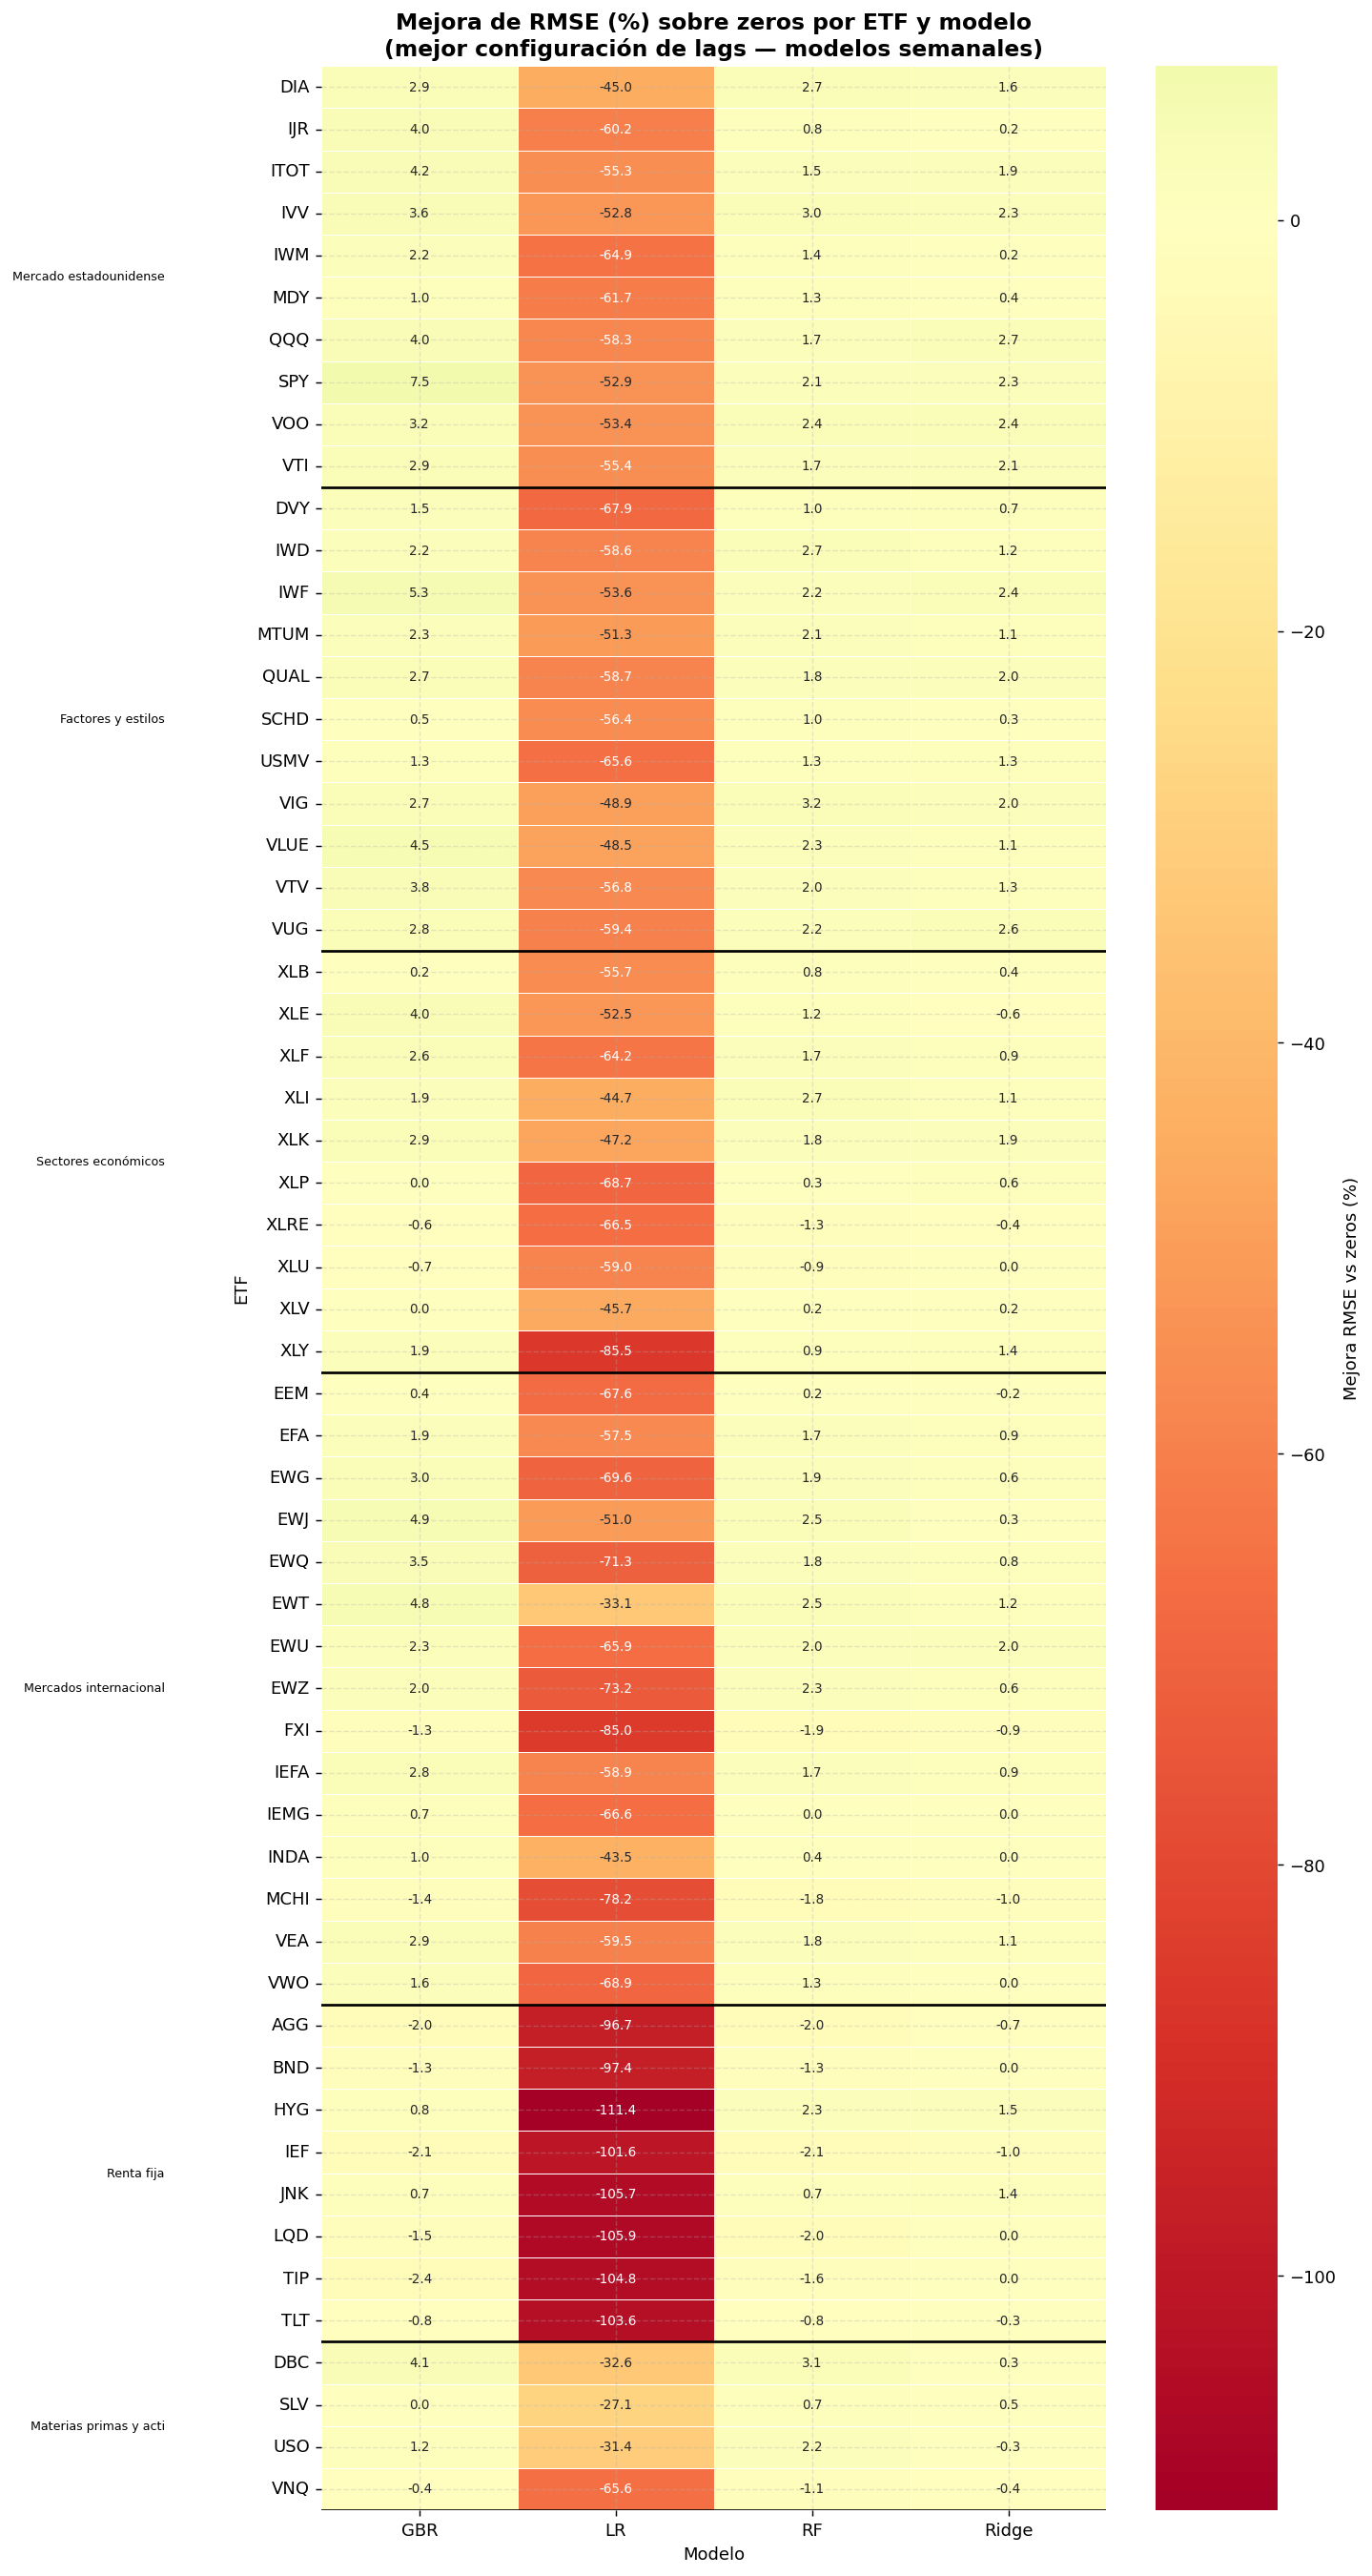

In [24]:
import seaborn as sns
df_hmap = (df_base.sort_values(["ETF","Método","RMSE"])
           .groupby(["ETF","Método"], as_index=False).first())
df_hmap["Mej_RMSE"] = ((df_hmap["RMSE_zeros"]-df_hmap["RMSE"])/df_hmap["RMSE_zeros"]*100).round(1)
pivot_hmap = df_hmap.pivot(index="ETF", columns="Método", values="Mej_RMSE")
pivot_hmap.columns = [c.replace("GradientBoostingRegressor","GBR")
                       .replace("RandomForestRegressor","RF")
                       .replace("LinearRegression","LR") for c in pivot_hmap.columns]
orden_etf_hmap = []
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    orden_etf_hmap.extend(sorted(etfs_g))
pivot_hmap = pivot_hmap.reindex([e for e in orden_etf_hmap if e in pivot_hmap.index])
fig, ax = plt.subplots(figsize=(11, max(9, len(pivot_hmap)*0.36)))
sns.heatmap(pivot_hmap, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.3, ax=ax,
            cbar_kws={"label":"Mejora RMSE vs zeros (%)"},
            annot_kws={"size":7.5})
y_pos_h = 0
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    n_g = sum(1 for e in etfs_g if e in pivot_hmap.index)
    if n_g:
        ax.axhline(y_pos_h+n_g, color="black", linewidth=1.5)
        ax.text(-0.2, y_pos_h+n_g/2, g[:22], ha="right", va="center",
                fontsize=7, transform=ax.get_yaxis_transform())
        y_pos_h += n_g
ax.set_title(
    f"Mejora de RMSE (%) sobre zeros por ETF y modelo\n"
    f"(mejor configuración de lags — modelos semanales)",
    fontsize=13, fontweight="bold")
ax.set_ylabel("ETF"); ax.set_xlabel("Modelo")
plt.tight_layout(); plt.show()

### BASELINE

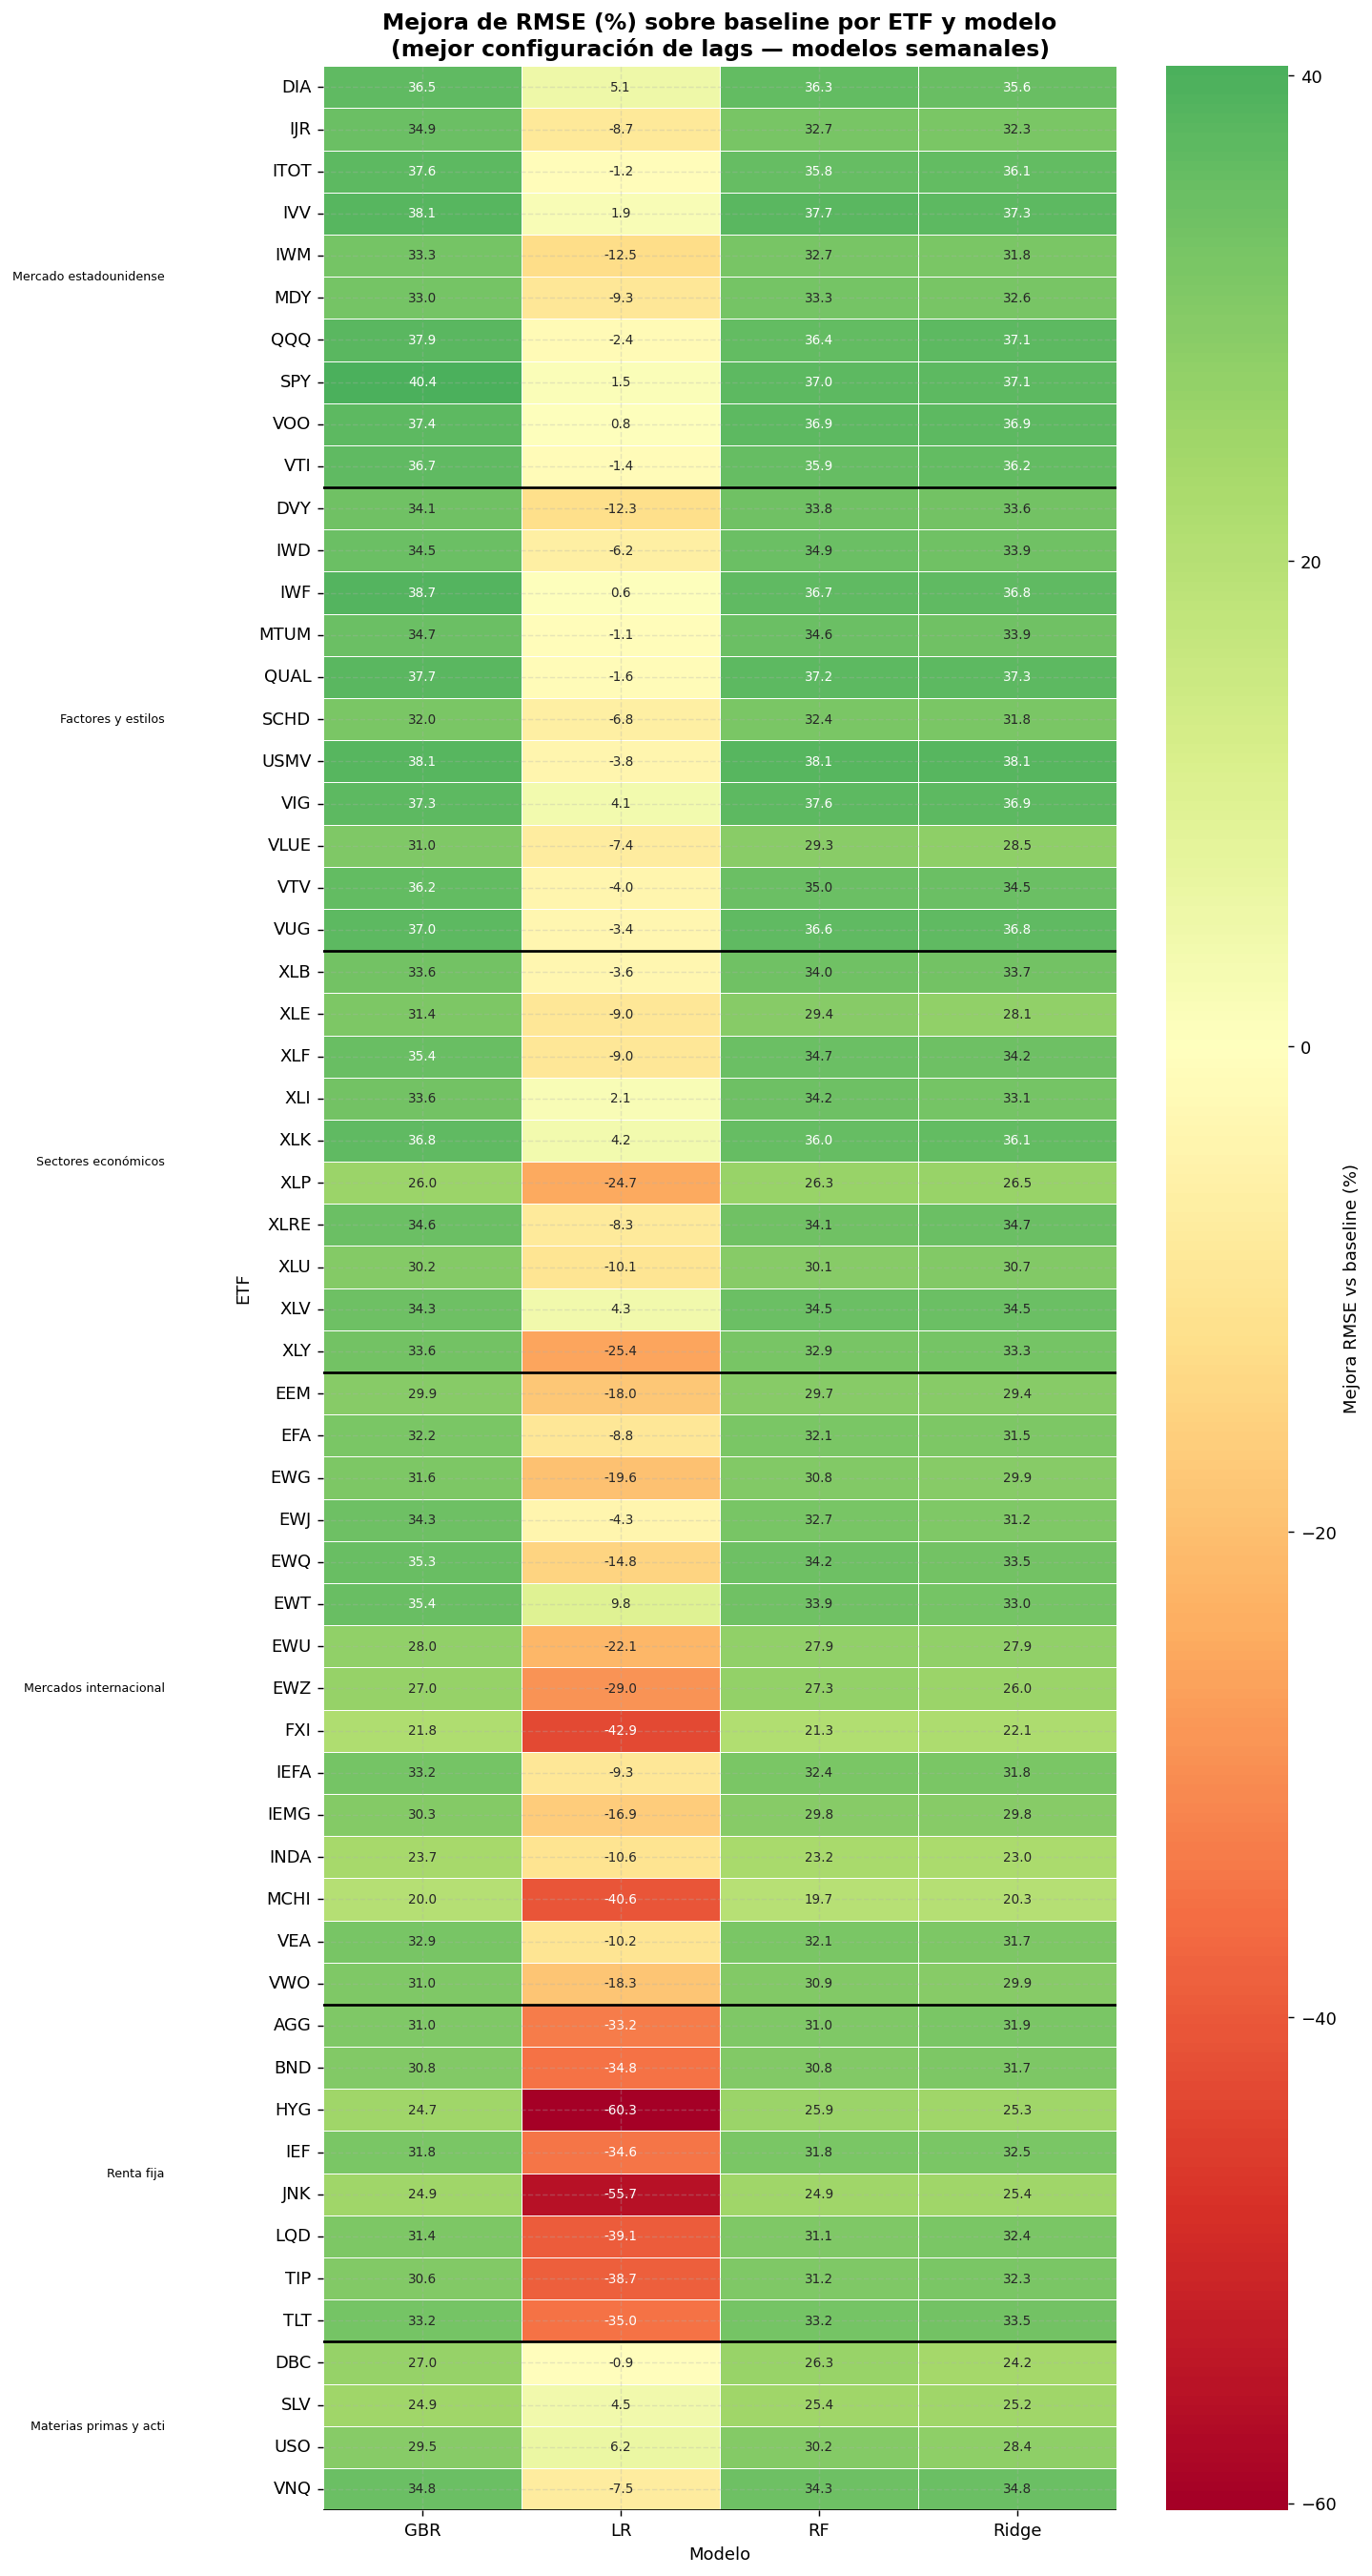

In [25]:
import seaborn as sns
df_hmap = (df_base.sort_values(["ETF","Método","RMSE"])
           .groupby(["ETF","Método"], as_index=False).first())
df_hmap["Mej_RMSE"] = ((df_hmap["RMSE_baseline"]-df_hmap["RMSE"])/df_hmap["RMSE_baseline"]*100).round(1)
pivot_hmap = df_hmap.pivot(index="ETF", columns="Método", values="Mej_RMSE")
pivot_hmap.columns = [c.replace("GradientBoostingRegressor","GBR")
                       .replace("RandomForestRegressor","RF")
                       .replace("LinearRegression","LR") for c in pivot_hmap.columns]
orden_etf_hmap = []
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    orden_etf_hmap.extend(sorted(etfs_g))
pivot_hmap = pivot_hmap.reindex([e for e in orden_etf_hmap if e in pivot_hmap.index])
fig, ax = plt.subplots(figsize=(11, max(9, len(pivot_hmap)*0.36)))
sns.heatmap(pivot_hmap, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.3, ax=ax,
            cbar_kws={"label":"Mejora RMSE vs baseline (%)"},
            annot_kws={"size":7.5})
y_pos_h = 0
for g in ORDEN_GRUPOS:
    etfs_g = [e for e in GRUPOS_ETF.get(g,[]) if e in pivot_hmap.index and e not in ETF_ELIMINADOS]
    n_g = sum(1 for e in etfs_g if e in pivot_hmap.index)
    if n_g:
        ax.axhline(y_pos_h+n_g, color="black", linewidth=1.5)
        ax.text(-0.2, y_pos_h+n_g/2, g[:22], ha="right", va="center",
                fontsize=7, transform=ax.get_yaxis_transform())
        y_pos_h += n_g
ax.set_title(
    f"Mejora de RMSE (%) sobre baseline por ETF y modelo\n"
    f"(mejor configuración de lags — modelos semanales)",
    fontsize=13, fontweight="bold")
ax.set_ylabel("ETF"); ax.set_xlabel("Modelo")
plt.tight_layout(); plt.show()

El heatmap muestra de un vistazo dónde funciona bien cada modelo y dónde no.

La columna de LR (Regresión Lineal) aparece en rojo en casi todos los ETFs, lo que confirma que nunca es una buena opción en este problema.

Las columnas de GBR, RF y Ridge son mayoritariamente verdes, con mejoras de entre el 25 % y el 35 % en la mayoría de casos. La intensidad del verde es bastante uniforme dentro de cada grupo de activos, lo que indica que el modelo semanal se comporta de forma parecida con ETFs de la misma categoría.

Los ETFs de renta fija tienen los verdes más intensos porque sus retornos tienen más estructura y regularidad. Los de materias primas y emergentes tienen verdes más apagados porque son más difíciles de predecir.

## Distribución de mejora por grupo de activos

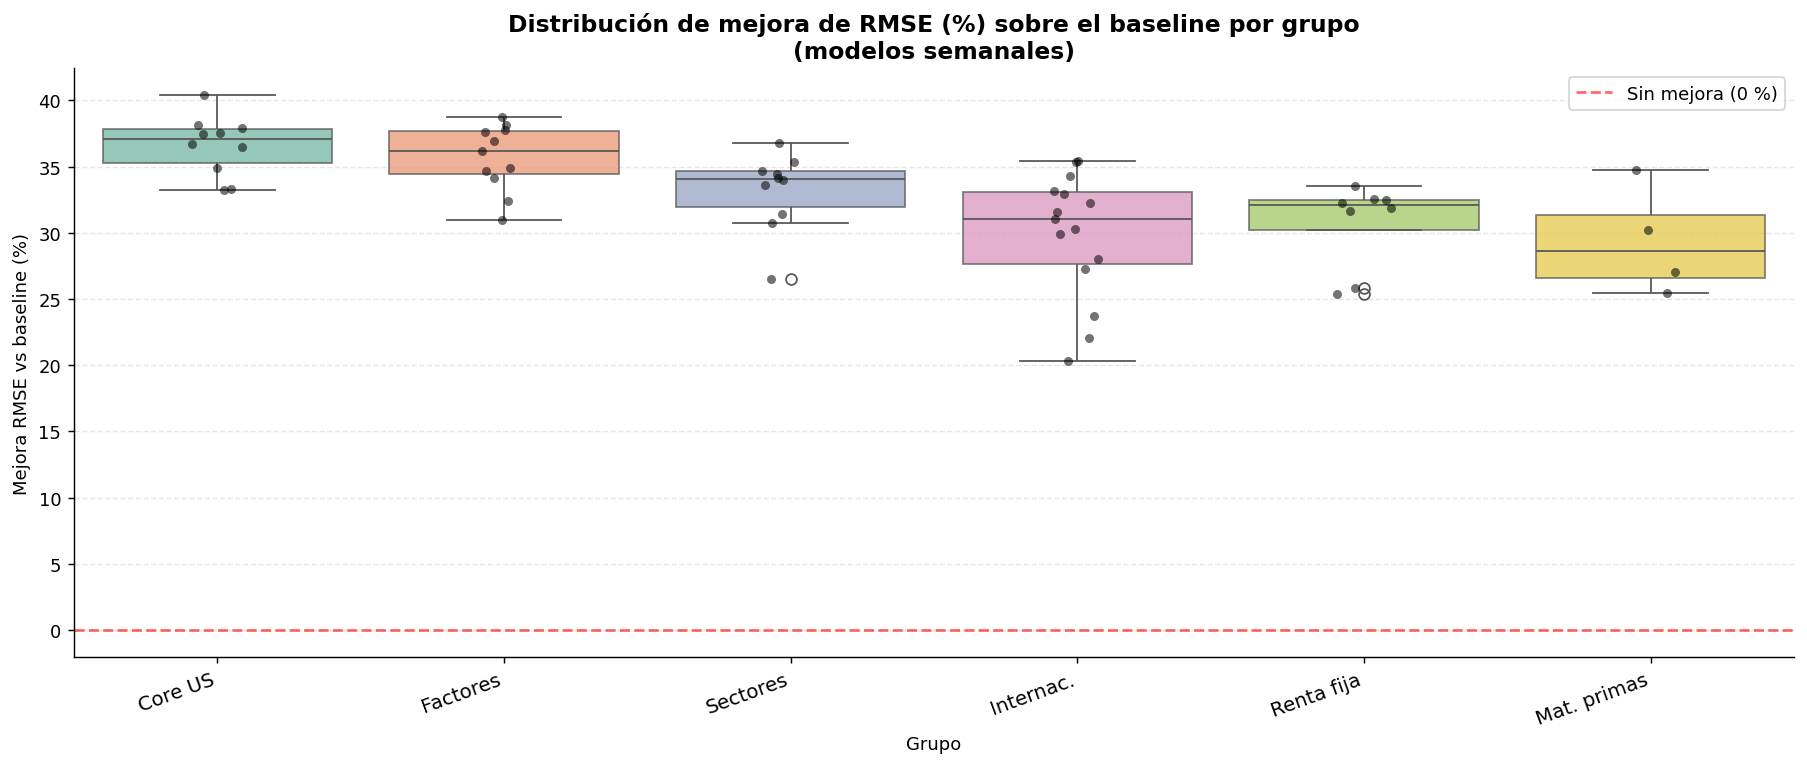

In [16]:
import seaborn as sns
df_bx = enriquecer_df(df_mejor)
grupos_pres = [g for g in ORDEN_GRUPOS if g in df_bx["Grupo"].values]
df_bx = df_bx[df_bx["Grupo"].isin(grupos_pres)].copy()
etiq_g = {"Mercado estadounidense (Core US)":"Core US","Factores y estilos":"Factores",
            "Sectores económicos":"Sectores","Mercados internacionales":"Internac.",
            "Renta fija":"Renta fija","Materias primas y activos reales":"Mat. primas"}
df_bx["Grupo_c"] = df_bx["Grupo"].map(etiq_g).fillna(df_bx["Grupo"])
orden_c = [etiq_g.get(g,g) for g in grupos_pres]
fig, ax = plt.subplots(figsize=(14,6))
sns.boxplot(data=df_bx, x="Grupo_c", y="Mej_RMSE_baseline(%)",
            palette="Set2", ax=ax, order=orden_c, boxprops=dict(alpha=0.75))
sns.stripplot(data=df_bx, x="Grupo_c", y="Mej_RMSE_baseline(%)",
              color="black", size=5, alpha=0.55, ax=ax, order=orden_c, jitter=True)
ax.axhline(0, color="red", linestyle="--", alpha=0.6, linewidth=1.5, label="Sin mejora (0 %)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=11)
ax.set_title(
    f"Distribución de mejora de RMSE (%) sobre el baseline por grupo\n(modelos semanales)",
    fontsize=13, fontweight="bold")
ax.set_xlabel("Grupo"); ax.set_ylabel("Mejora RMSE vs baseline (%)")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

Todos los grupos tienen la caja por encima de cero, lo que confirma que la mejora sobre el baseline se da en todas las categorías de activos, no solo en algunas.

El grupo de mercado americano (Core US) tiene la caja más compacta: los grandes ETFs de bolsa americana se comportan de forma parecida entre sí y el modelo los trata de forma uniforme.

Los mercados internacionales tienen más dispersión porque incluyen tanto mercados desarrollados (EFA, VEA) como emergentes (EEM, FXI), que tienen características muy distintas.

La renta fija tiene medianas altas porque los bonos tienen más autocorrelación que las acciones, es decir, el pasado predice algo mejor el futuro en ese tipo de activos.

Los puntos sueltos fuera de las cajas son ETFs concretos que el modelo predice especialmente bien o mal dentro de su grupo.

## ¿Qué modelo y qué número de lags se eligen con más frecuencia?

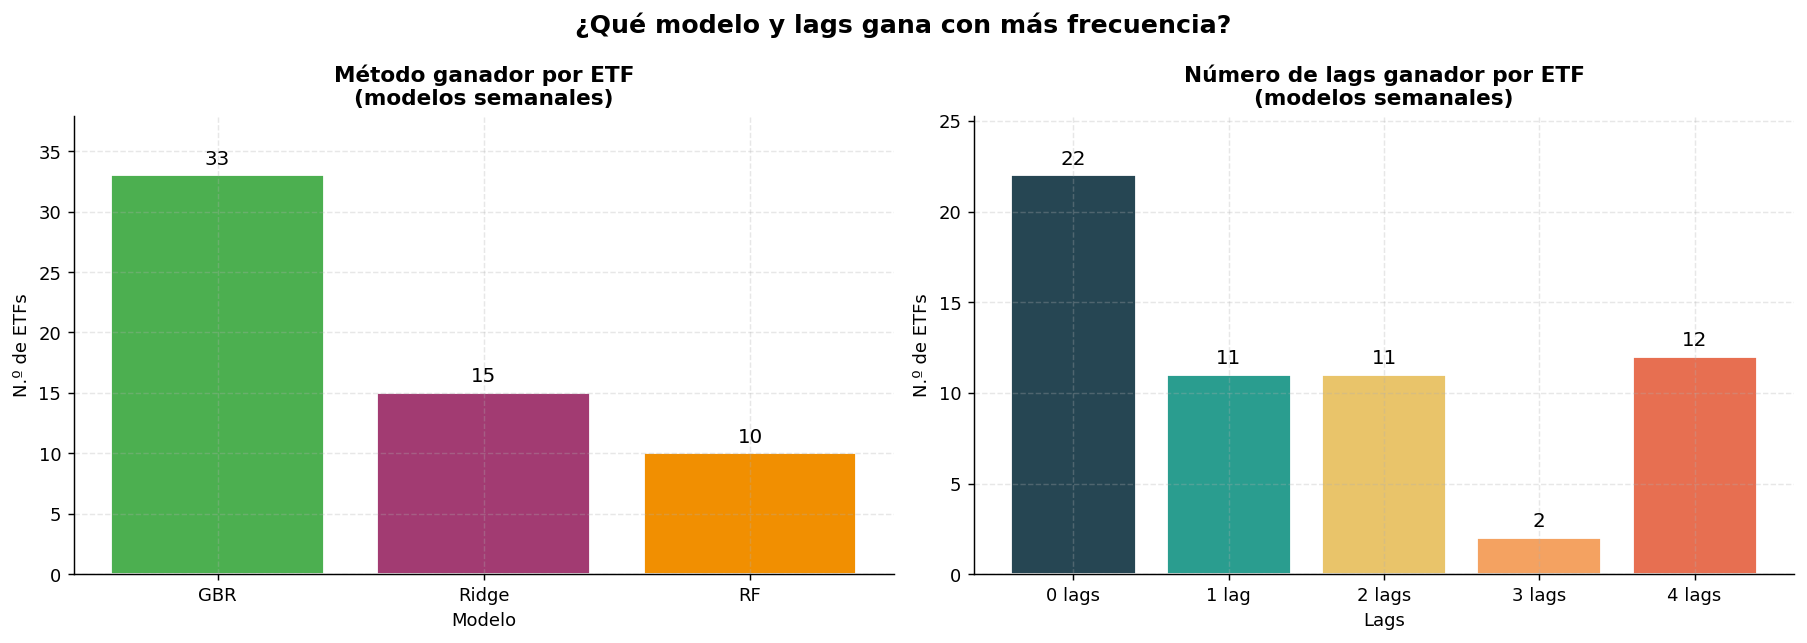

In [17]:
df_cfg = enriquecer_df(df_mejor)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
mc = df_cfg["Método_c"].value_counts()
cols_met = [COLORES_METODO.get(
    m.replace("GBR","GradientBoostingRegressor").replace("RF","RandomForestRegressor").replace("LR","LinearRegression"),"#888")
    for m in mc.index]
bm = axes[0].bar(mc.index, mc.values, color=cols_met, edgecolor="white")
axes[0].bar_label(bm, fontsize=11, padding=4)
axes[0].set_title(f"Método ganador por ETF\n(modelos semanales)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Modelo"); axes[0].set_ylabel("N.º de ETFs")
axes[0].set_ylim(0, mc.max()*1.15)
lags_ord = ["0 lags","1 lag","2 lags","3 lags","4 lags"]; arch_ord = ["df_semanal.csv","df_semanal_1.csv","df_semanal_2.csv","df_semanal_3.csv","df_semanal_4.csv"]
lc = df_cfg["Lags"].value_counts().reindex(lags_ord).fillna(0)
cols_lag = [COLORES_ARCHIVO.get(a,"#888") for a in arch_ord]
bl = axes[1].bar(lc.index, lc.values, color=cols_lag, edgecolor="white")
axes[1].bar_label(bl, fontsize=11, padding=4)
axes[1].set_title(f"Número de lags ganador por ETF\n(modelos semanales)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Lags"); axes[1].set_ylabel("N.º de ETFs")
axes[1].set_ylim(0, max(lc.max()*1.15, 1))
fig.suptitle("¿Qué modelo y lags gana con más frecuencia?", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

El gráfico de la izquierda muestra qué modelo gana más veces cuando elegimos el mejor por ETF. Si Ridge o GBR dominan, indica que la regularización y el boosting son las técnicas más útiles para este tipo de datos semanales.

El gráfico de la derecha muestra que la mayoría de ETFs tienen su mejor resultado con 0 lags. Esto reafirma lo que ya habíamos visto: añadir más histórico no ayuda. El modelo captura la información que necesita con las variables del período actual.

Si hay ETFs que prefieren 1 o 2 lags, pueden ser activos con algo más de memoria en sus retornos, como algunos bonos o materias primas.

## Mejor modelo para cada ETF, desglosado por grupo

In [18]:
df_mejor = (
    df_base
    .sort_values(["ETF", "RMSE", "MAE", "Archivo", "Método"])
    .drop_duplicates(subset=["ETF"], keep="first")
    .copy()
)

imprimir_tabla_por_grupos(
    df_mejor,
    "DE CADA ETF SELECCIONAMOS SU MEJOR MODELO Y ARCHIVO, agrupados por grupo"
)



DE CADA ETF SELECCIONAMOS SU MEJOR MODELO Y ARCHIVO, agrupados por grupo

MERCADO ESTADOUNIDENSE (CORE US) (10 ETFs)
        Lags Método     RMSE      MAE Mej.RMSE_base(%) Mej.RMSE_zeros(%) Mej.MAE_base(%) Mej.MAE_zeros(%)
ETF                                                                                                      
SPY   4 lags    GBR  0.00434  0.00324           40.38%             7.46%          38.52%            6.63%
DIA   2 lags    GBR  0.00434  0.00338           36.46%             2.91%          35.37%            3.15%
VOO   4 lags    GBR  0.00451  0.00353           37.45%             3.22%          32.89%           -2.02%
IVV   4 lags    GBR  0.00453  0.00342           38.11%             3.62%          35.35%            1.72%
ITOT  0 lags    GBR  0.00459  0.00348           37.55%             4.18%          35.20%            1.97%
VTI   0 lags    GBR  0.00464  0.00359           36.70%             2.93%          33.02%           -1.70%
MDY    1 lag     RF  0.00515  0.0

La tabla muestra el mejor resultado conseguido para cada ETF de forma individual, agrupado por tipo de activo.

Dentro de cada grupo el patrón es bastante consistente: los ETFs del mismo tipo de activo tienden a tener mejoras similares y a elegir el mismo modelo. Eso tiene sentido porque comparten muchas características de mercado.

Los grupos de renta fija y mercado americano tienen los mejores resultados en términos de mejora sobre baseline. Los de materias primas tienen mejoras más modestas pero también positivas.

El resumen al final de cada grupo indica cuántos ETFs de ese grupo consiguen superar también al benchmark de zeros, que es el umbral más difícil de batir.

## Porcentaje de éxito contra cada benchmark 

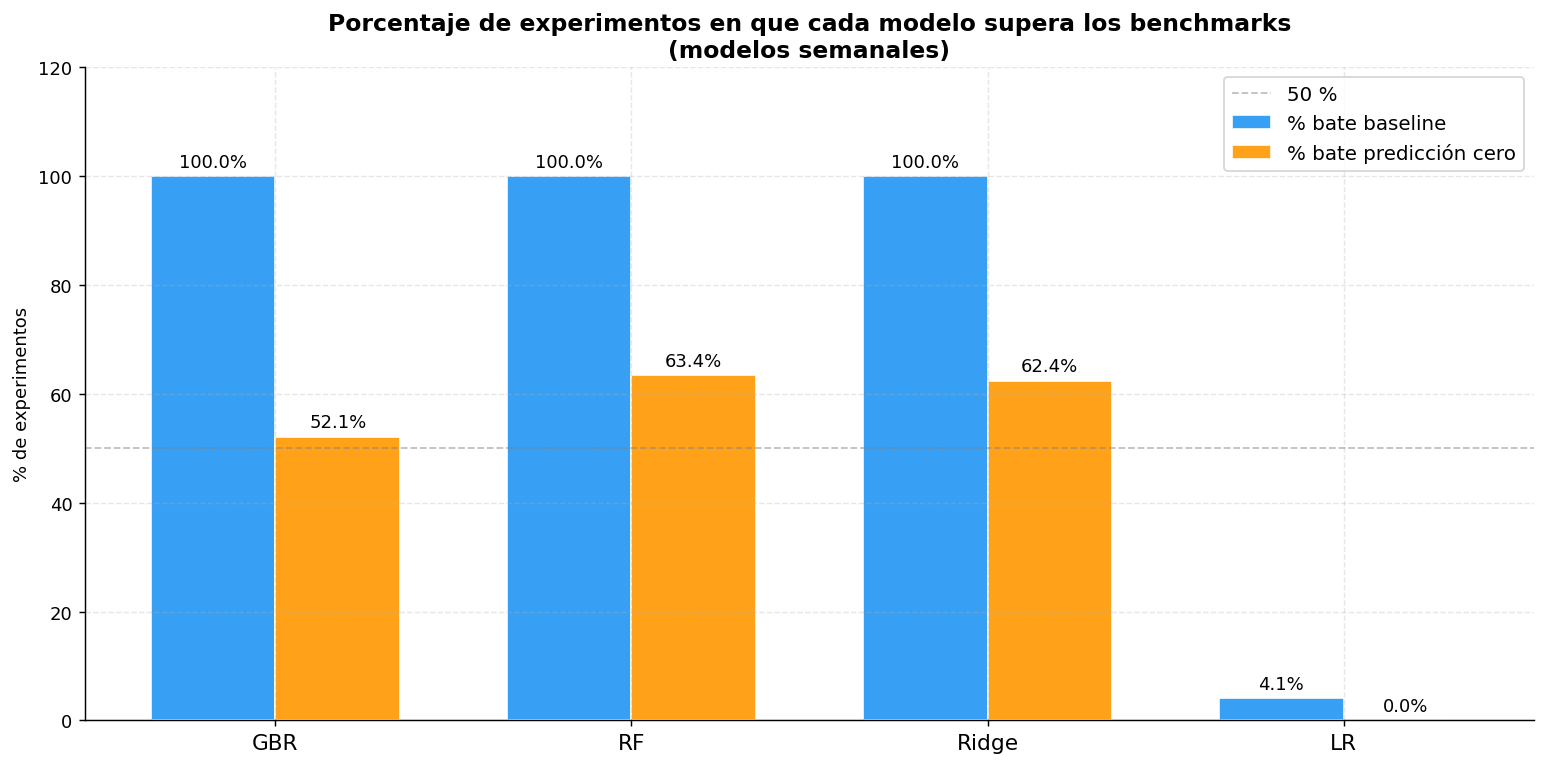

In [20]:
import numpy as np
tabla_bate = df_base.groupby("Método").agg(
    Pct_bate_baseline=("Bate_baseline", lambda x: round(x.mean()*100,1)),
    Pct_bate_zeros   =("Bate_zeros",    lambda x: round(x.mean()*100,1)),
    N_experimentos   =("RMSE","count")
).sort_values("Pct_bate_baseline", ascending=False)
metodos_bp = tabla_bate.index.tolist()
x_bp = np.arange(len(metodos_bp)); w = 0.35
fig, ax = plt.subplots(figsize=(12,6))
b1 = ax.bar(x_bp-w/2, tabla_bate["Pct_bate_baseline"], w,
            label="% bate baseline", color="#2196F3", edgecolor="white", alpha=0.9)
b2 = ax.bar(x_bp+w/2, tabla_bate["Pct_bate_zeros"], w,
            label="% bate predicción cero", color="#FF9800", edgecolor="white", alpha=0.9)
ax.bar_label(b1, fmt="%.1f%%", fontsize=10, padding=3)
ax.bar_label(b2, fmt="%.1f%%", fontsize=10, padding=3)
ax.axhline(50, color="gray", linestyle="--", alpha=0.5, linewidth=1, label="50 %")
ax.set_xticks(x_bp)
ax.set_xticklabels(
    [m.replace("GradientBoostingRegressor","GBR").replace("RandomForestRegressor","RF").replace("LinearRegression","LR")
     for m in metodos_bp], fontsize=12)
ax.set_title(f"Porcentaje de experimentos en que cada modelo supera los benchmarks\n(modelos semanales)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% de experimentos"); ax.set_ylim(0,120); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

El dato más destacado es que Ridge, RF y GBR baten al baseline en el 100 % de los experimentos. Esto significa que en ningún caso, para ningún ETF ni configuración de lags, el modelo es peor que copiar el último retorno observado. Es un resultado muy sólido.

El porcentaje contra la predicción de cero es más bajo, entre el 52 y el 63 %. Tiene lógica: predecir cero es ya una estrategia bastante buena para retornos semanales de mercado, así que superarla más de la mitad de las veces ya indica que el modelo está extrayendo algo de señal real.

La Regresión Lineal apenas supera el baseline en un 4 % de los casos. Prácticamente siempre es peor que no hacer nada, lo que confirma que no debe usarse sin regularización.

## Cómo cambia el RMSE al añadir más lags

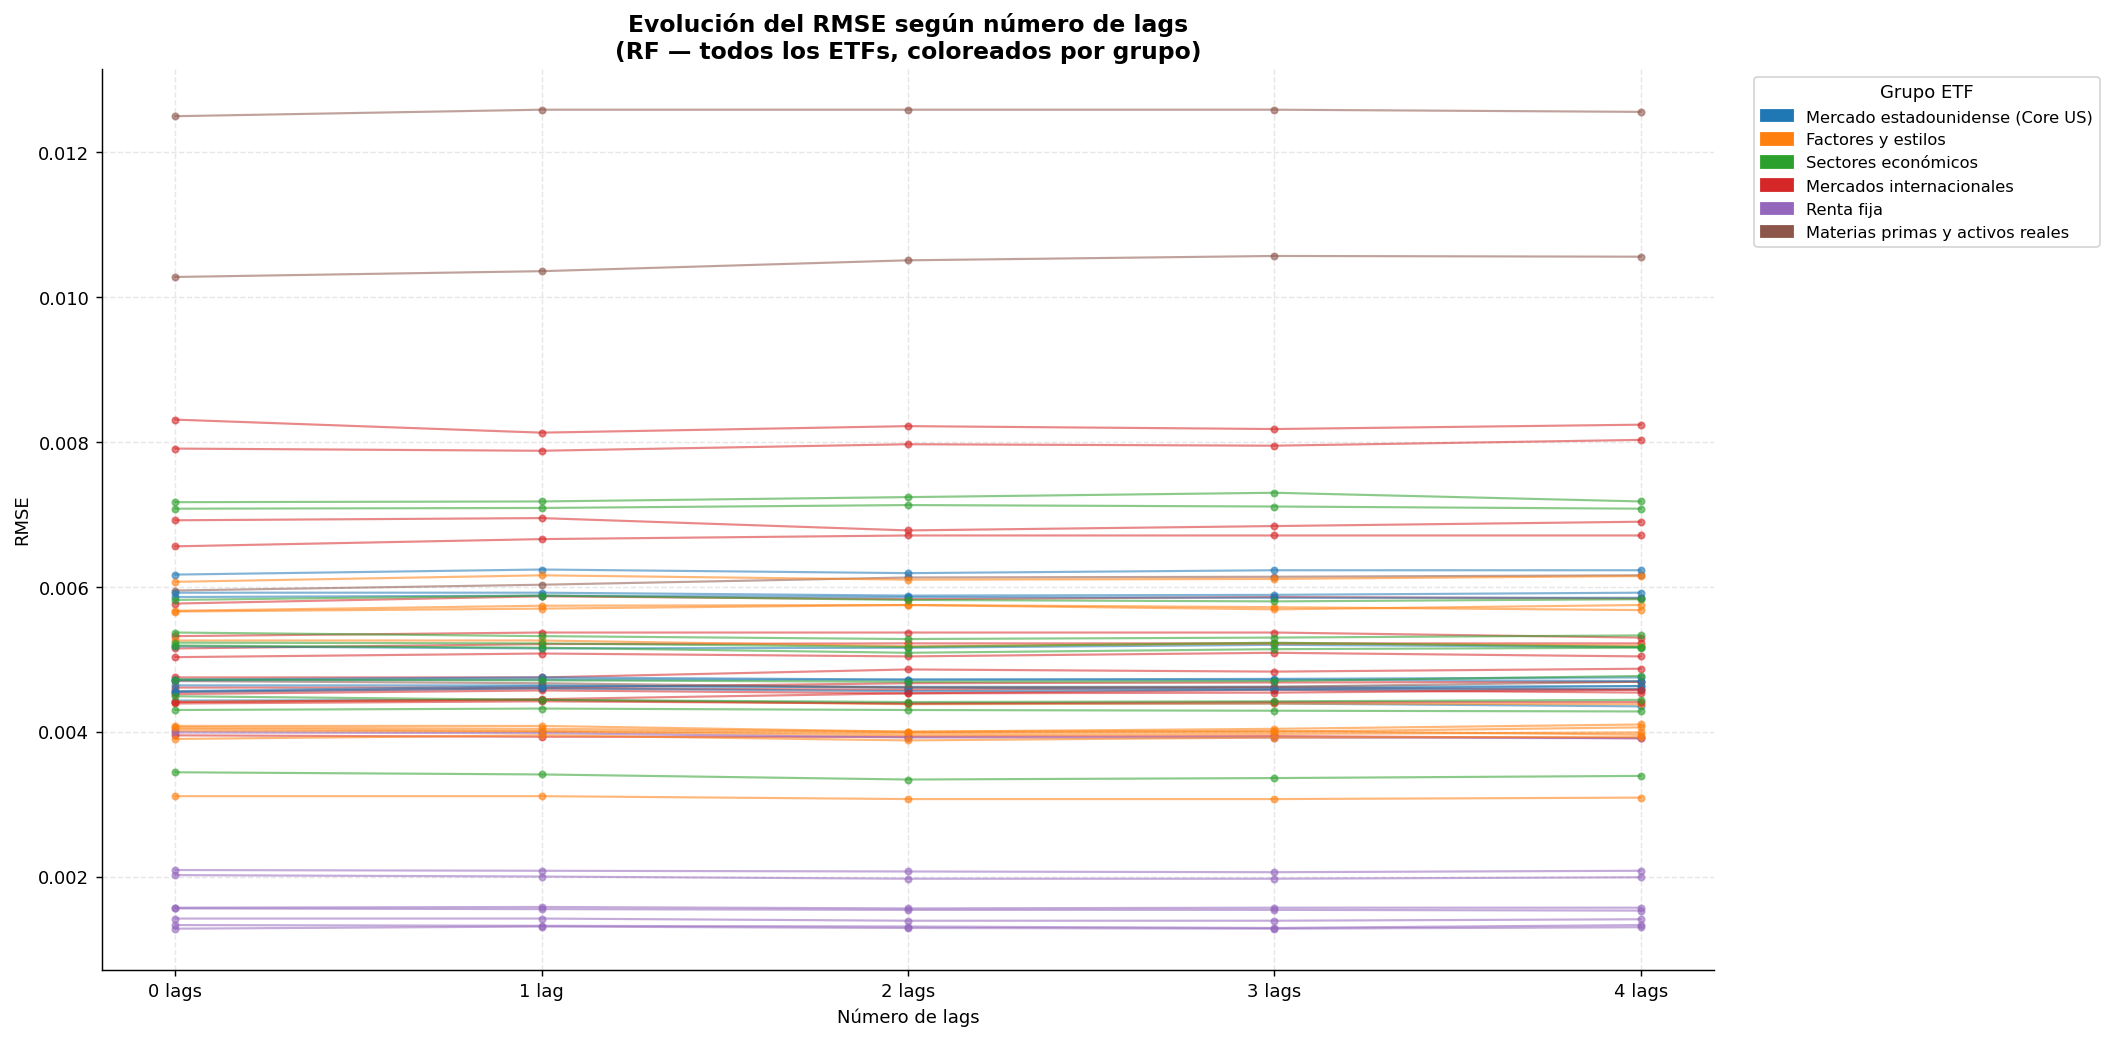

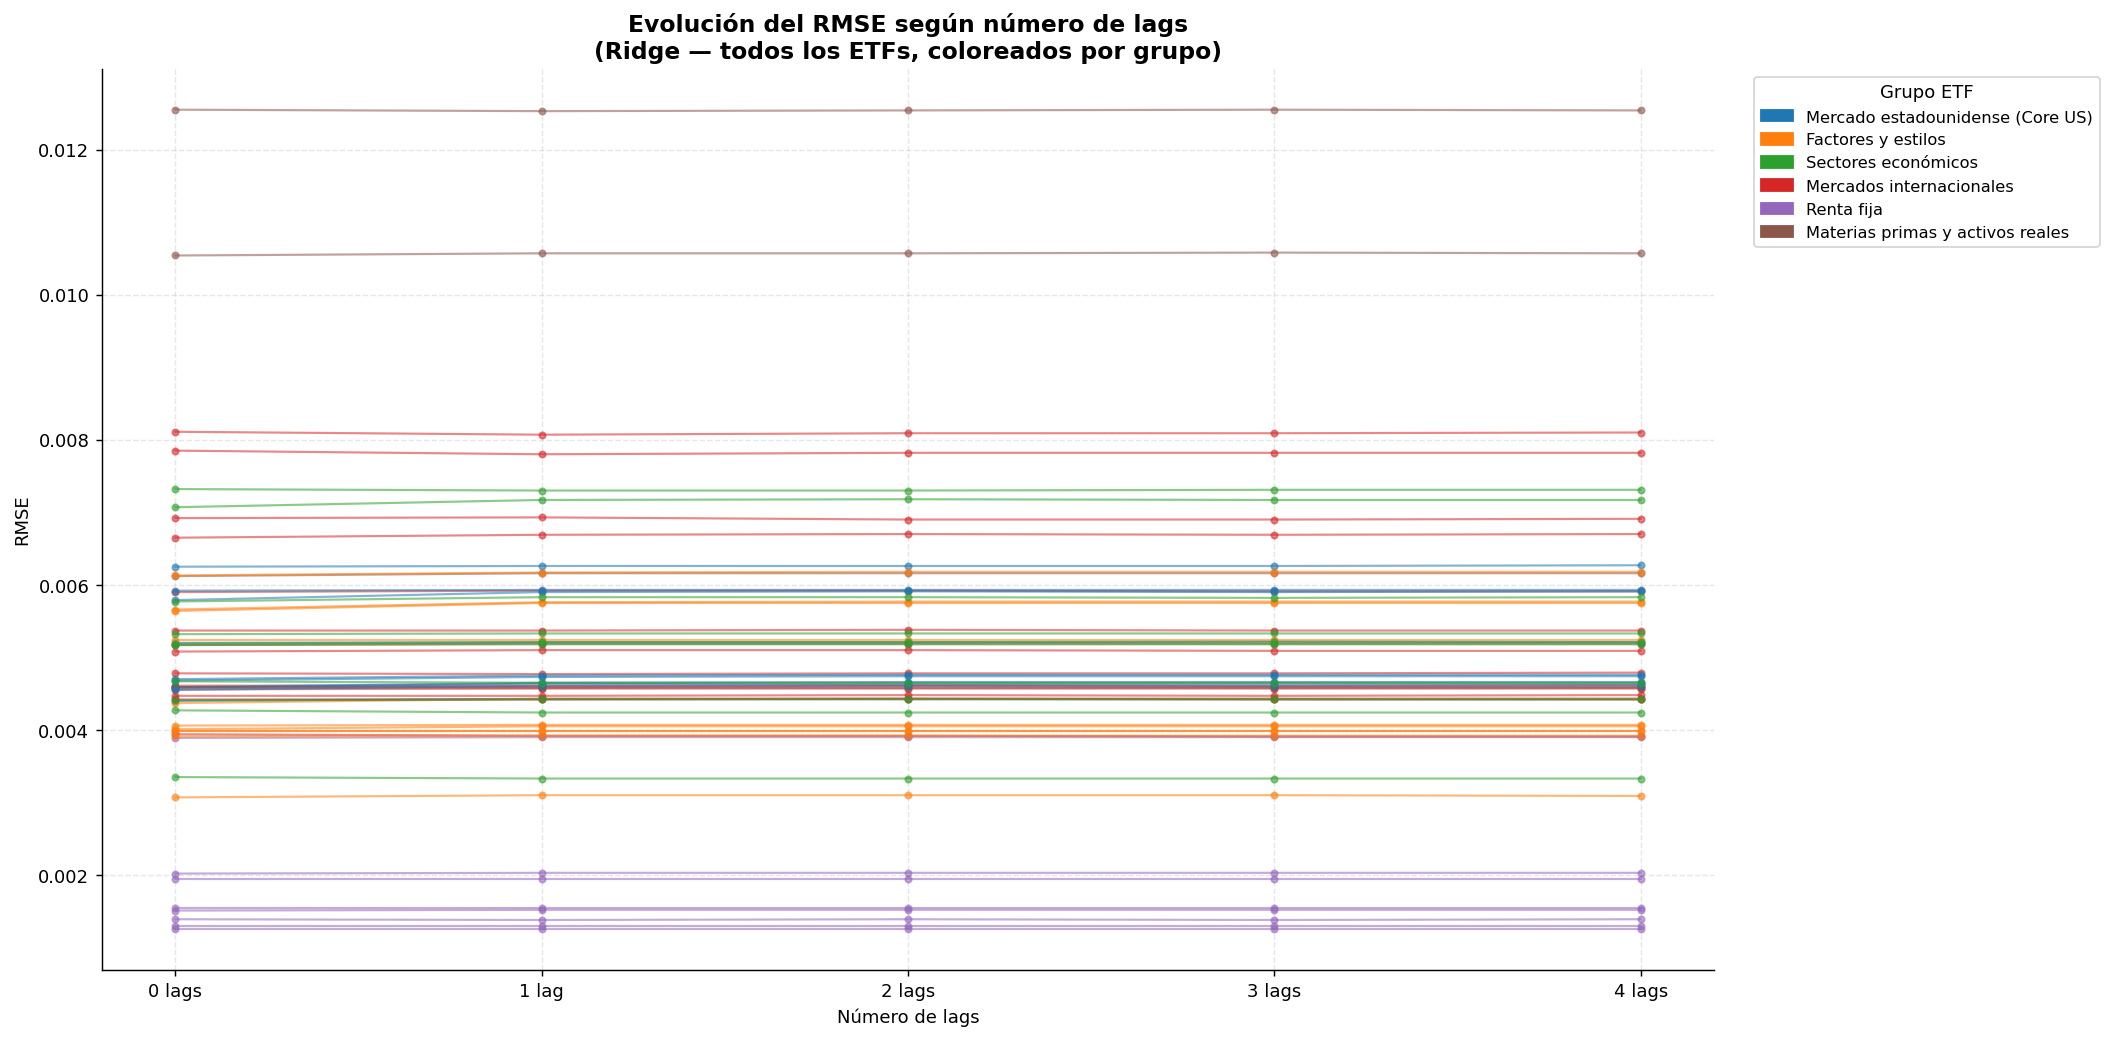

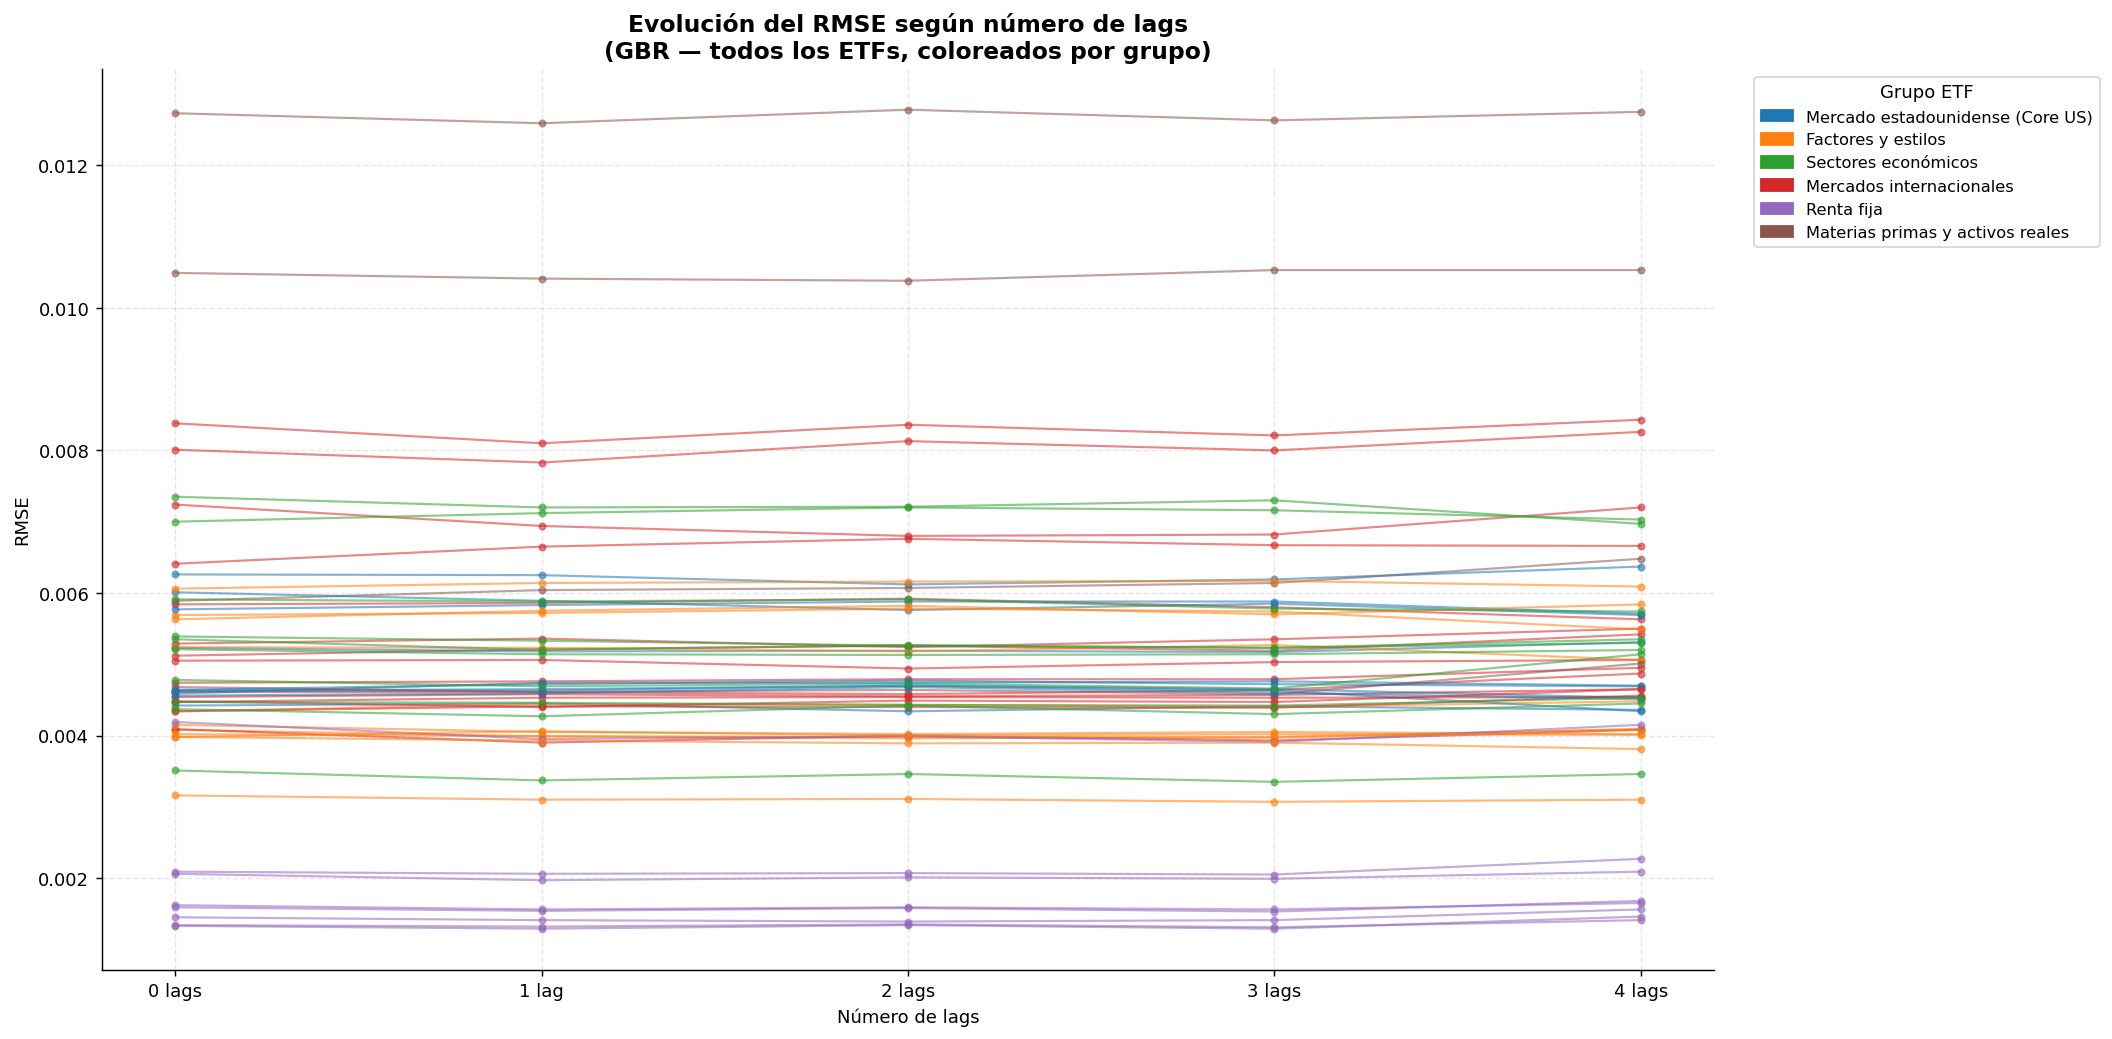

In [21]:

#  Evolución del RMSE según lags, coloreado por grupo
# Un gráfico por método

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Orden de los archivos / lags
archivos_ord2 = [
    "df_semanal.csv",
    "df_semanal_1.csv",
    "df_semanal_2.csv",
    "df_semanal_3.csv",
    "df_semanal_4.csv"
]

# Colores por grupo
COLORES_GRUPO = {
    "Mercado estadounidense (Core US)": "#1f77b4",
    "Factores y estilos": "#ff7f0e",
    "Sectores económicos": "#2ca02c",
    "Mercados internacionales": "#d62728",
    "Renta fija": "#9467bd",
    "Materias primas y activos reales": "#8c564b",
    "Sin grupo": "#7f7f7f",
}

# Copia para graficar
df_plot = df.copy()

# Asegurar columnas necesarias
df_plot["RMSE"] = pd.to_numeric(df_plot["RMSE"], errors="coerce")
df_plot["Grupo"] = df_plot["ETF"].map(etf_to_grupo).fillna("Sin grupo")

# Si quieres excluir ETFs eliminados también del gráfico:
ETF_ELIMINADOS = {"BIL", "EWY", "GLD", "IAU", "SHY"}
df_plot = df_plot[~df_plot["ETF"].isin(ETF_ELIMINADOS)].copy()


def nombre_corto_metodo(m):
    return (
        m.replace("GradientBoostingRegressor", "GBR")
         .replace("RandomForestRegressor", "RF")
         .replace("LinearRegression", "LR")
    )


def graficar_rmse_lags_todos(df_in, metodo):
    sub_met = df_in[df_in["Método"] == metodo].copy()

    if sub_met.empty:
        print(f"No hay datos para el método: {metodo}")
        return

    etfs_todos = sorted(sub_met["ETF"].dropna().unique())

    fig, ax = plt.subplots(figsize=(16, 9))

    for etf in etfs_todos:
        sub_etf = sub_met[sub_met["ETF"] == etf].copy()
        sub_etf = sub_etf.set_index("Archivo").reindex(archivos_ord2)

        grupo_etf = sub_met.loc[sub_met["ETF"] == etf, "Grupo"].iloc[0]
        color_etf = COLORES_GRUPO.get(grupo_etf, "#888888")

        ax.plot(
            [LAGS_LABEL.get(a, a) for a in archivos_ord2],
            sub_etf["RMSE"].values,
            marker="o",
            linestyle="-",
            linewidth=1.2,
            markersize=3.5,
            alpha=0.55,
            color=color_etf
        )

    # Leyenda por grupos
    grupos_presentes = [
        g for g in ORDEN_GRUPOS + ["Sin grupo"]
        if g in sub_met["Grupo"].unique()
    ]

    patches = [
        mpatches.Patch(color=COLORES_GRUPO[g], label=g)
        for g in grupos_presentes
    ]

    ax.legend(
        handles=patches,
        title="Grupo ETF",
        fontsize=9,
        title_fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    metodo_txt = nombre_corto_metodo(metodo)

    ax.set_title(
        f"Evolución del RMSE según número de lags\n"
        f"({metodo_txt} — todos los ETFs, coloreados por grupo)",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)

    # plt.tight_layout()
    # nombre_fig = f"G13_rmse_lags_todos_{metodo_txt}.png"
    # plt.savefig(nombre_fig, dpi=150, bbox_inches="tight")
    # plt.show()

    # print(f"Gráfico guardado: {nombre_fig}")


#
# MÉTODOS A GRAFICAR
#

mejor_metodo_global = df_plot.groupby("Método")["RMSE"].mean().idxmin()

metodos_a_graficar = [
    mejor_metodo_global,
    "Ridge",
    "RandomForestRegressor",
    "GradientBoostingRegressor"
]

# quitar duplicados por si el mejor global ya es Ridge o RF
metodos_a_graficar = list(dict.fromkeys(metodos_a_graficar))

for metodo in metodos_a_graficar:
    graficar_rmse_lags_todos(df_plot, metodo)

Las líneas de cada ETF son casi planas de izquierda a derecha: el RMSE apenas cambia al pasar de 0 a 4 lags. Esto confirma una vez más que añadir más semanas de histórico no mejora las predicciones.

Los ETFs de materias primas (líneas marrones) aparecen en la parte alta del gráfico porque tienen más volatilidad, no porque el modelo funcione peor con ellos en términos relativos. Los de renta fija (líneas moradas) están abajo porque sus retornos son más pequeños en magnitud.

Si hubiera algún ETF con una línea con pendiente negativa clara (que bajara de izquierda a derecha), significaría que ese activo tiene memoria semanales que el modelo puede aprovechar. En general eso no ocurre de forma sistemática.